# SATS Ground Operations — Off Chocks Performance Report
**Prepared by:** SATS Operations Intern &nbsp;|&nbsp; **Period:** Aug 2025 – Apr 2026

---

## Executive Summary

This report analyses **125,508 SATS-handled turnaround flights** across 9 months (Aug 2025 – Apr 2026) to quantify how inbound arrival delays affect off-chocks punctuality.

**Key findings:**

- **35.7%** of SATS flights push back on time (off chocks ≤ 0 min). Nearly two-thirds depart late.
- When inbound aircraft arrive early or on time, the on-time off chocks rate is **46.1%**. When they arrive more than 15 min late, it collapses to **16.4%** — a **–29.8 percentage-point drop**.
- **39.2%** of inbound aircraft arrive more than 4 min late; **23.5%** arrive more than 15 min late, directly constraining ground teams before turnaround even begins.
- **Singapore home carriers (SQ & TR)** — 56.9% of the dataset — consistently outperform other SATS-handled carriers, particularly on late-arriving aircraft, suggesting a home-base recovery advantage.
- The relationship between inbound delay tier and off-chocks performance is **consistent across all 10 months**, ruling out one-off events as the cause.

---

In [1]:
import warnings, json, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.1f}'.format)

CACHE_PATH = '/Users/prathosh/Desktop/Sats Project/Data/flights_cache.parquet'
GHA_PATH   = '/Users/prathosh/Desktop/Sats Project/Data/(SATS) 2. GHAs List of Airlines Jan 26  (1).xlsx'

df = pd.read_parquet(CACHE_PATH)
for c in ['arr_scheduled','arr_actual','dep_scheduled','dep_actual']:
    df[c] = pd.to_datetime(df[c], errors='coerce', utc=True)

gha = pd.read_excel(GHA_PATH, sheet_name='Sheet2', header=0)
gha.columns = ['airline_name','fsc_lcc','carrier','sats_or_not']
SATS = set(gha['carrier'].astype(str).str.strip().dropna())
HOME = ['SQ', 'TR']

print(f'Raw dataset: {len(df):,} rows, {df["carrier"].nunique()} unique carriers')


Raw dataset: 386,545 rows, 132 unique carriers


---
## 1. Data Overview
The raw dataset covers all flight movements processed through SATS-handled stations. The section below shows the full date range, which airlines appear in the data, and the monthly volume specifically for SATS-handled carriers.

In [2]:
# Date range is derived from the working dataset (Aug 2025 – May 2026)
# Raw data has sparse Jun/Jul 2025 entries (< 10 flights) that are excluded
df_dep = df[df['dep_actual'].notna()].copy()
df_dep['month_str'] = df_dep['dep_actual'].dt.to_period('M').astype(str)

# Only count months that have meaningful volume (≥ 100 flights)
monthly_counts = df_dep.groupby('month_str').size()
valid_months   = monthly_counts[monthly_counts >= 100].index
date_min = pd.Period(valid_months.min(), 'M').to_timestamp().strftime('%b %Y')
date_max = pd.Period(valid_months.max(), 'M').to_timestamp().strftime('%b %Y')

print(f'Analysis period      : {date_min}  →  {date_max}')
print(f'Total rows (full db) : {len(df_dep):,}')
print(f'Unique carriers      : {df_dep["carrier"].nunique()}')
print(f'SATS-handled carriers: {len([c for c in SATS if c in df_dep["carrier"].unique()])}')


Analysis period      : Aug 2025  →  May 2026
Total rows (full db) : 150,034
Unique carriers      : 125
SATS-handled carriers: 81


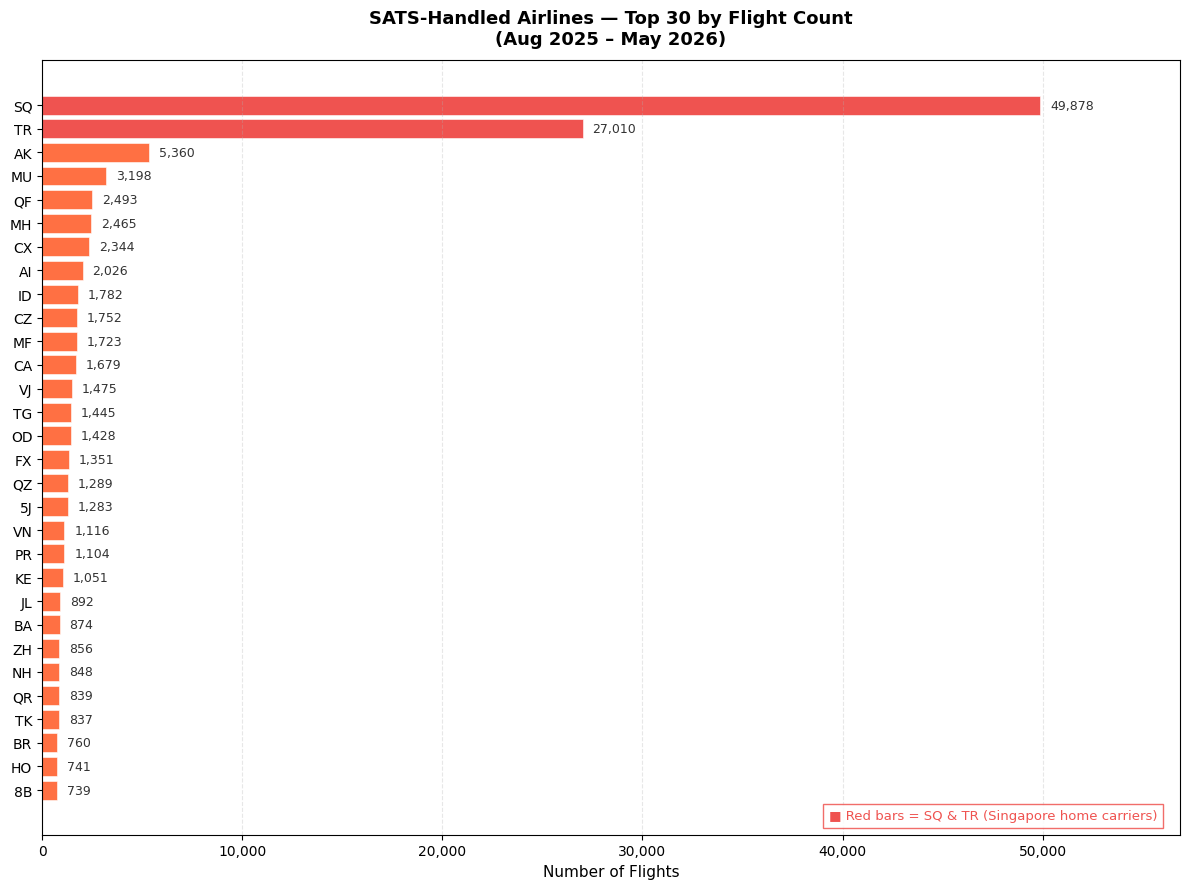

In [3]:
# ── SATS-Handled Airlines — Top 30 by Flight Count ──────────────────────
df_dep2   = df[df['dep_actual'].notna()].copy()
sats_top30 = df_dep2[df_dep2['carrier'].isin(SATS)]['carrier'].value_counts().head(30)

bar_color = '#FF7043'
colors = [('#EF5350' if c in HOME else bar_color) for c in sats_top30.index]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(sats_top30.index[::-1], sats_top30.values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, sats_top30.values[::-1]):
    ax.text(bar.get_width() + sats_top30.values.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9, color='#333')
ax.set_xlabel('Number of Flights', fontsize=11)
ax.set_title('SATS-Handled Airlines — Top 30 by Flight Count\n(Aug 2025 – May 2026)',
             fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax.set_xlim(0, sats_top30.values.max() * 1.14)
ax.grid(axis='x', ls='--', alpha=0.3)
ax.text(0.98, 0.02, '■ Red bars = SQ & TR (Singapore home carriers)',
        transform=ax.transAxes, ha='right', fontsize=9.5, color='#EF5350',
        bbox=dict(fc='white', ec='#EF5350', alpha=0.85, pad=4))
plt.tight_layout()
plt.show()


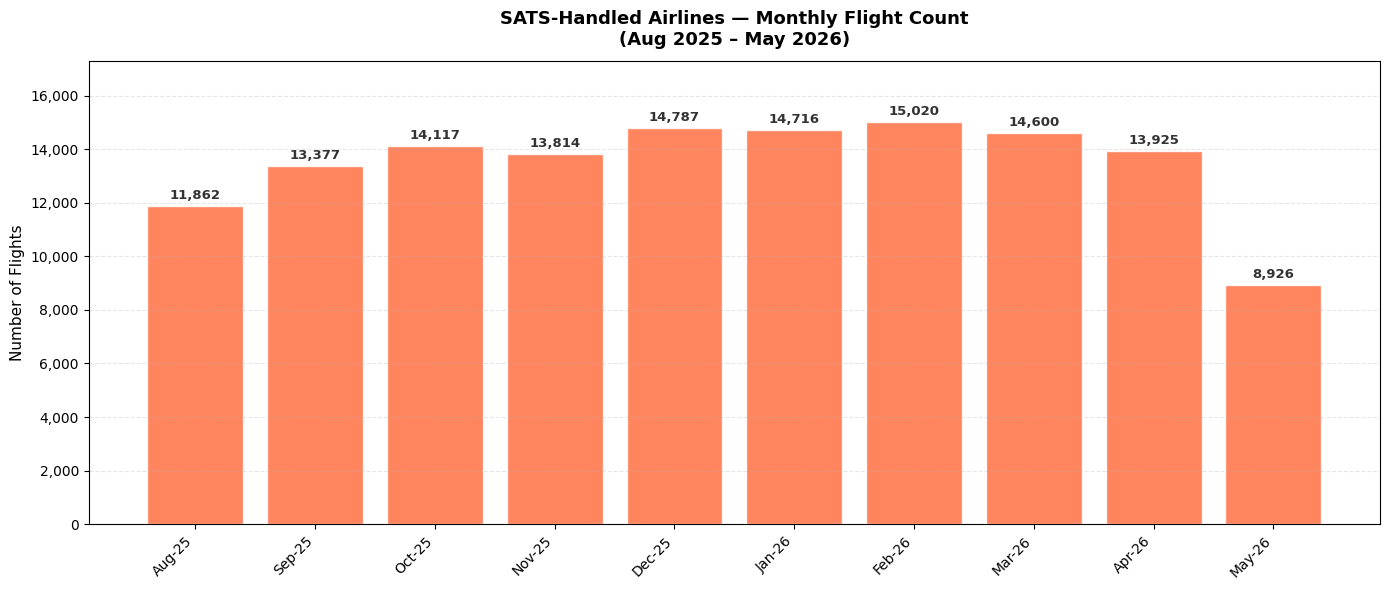

In [4]:
# ── SATS-Handled Airlines — Monthly Flight Count ─────────────────────────
df_dep3 = df[df['dep_actual'].notna()].copy()
df_dep3['month_str'] = df_dep3['dep_actual'].dt.to_period('M').astype(str)
monthly_sats = (df_dep3[df_dep3['carrier'].isin(SATS)]
                .groupby('month_str').size().sort_index())
# Keep only months with meaningful volume
monthly_sats = monthly_sats[monthly_sats >= 100]

months  = list(monthly_sats.index)
mlabels = [pd.Period(m,'M').to_timestamp().strftime('%b-%y') for m in months]
vals    = monthly_sats.values

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(vals)), vals, color='#FF7043', edgecolor='white', alpha=0.85)
for i, v in enumerate(vals):
    ax.text(i, v + vals.max()*0.01, f'{int(v):,}', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#333')
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(mlabels, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Number of Flights', fontsize=11)
ax.set_title('SATS-Handled Airlines — Monthly Flight Count\n(Aug 2025 – May 2026)',
             fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax.set_ylim(0, vals.max() * 1.15)
ax.grid(axis='y', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 2. Data Filtering & Methodology

Not all rows in the raw dataset are used for the off-chocks delay analysis. The table below shows exactly how the working dataset was built and why each step was applied.

| Step | Filter Applied | Flights Remaining | Reason |
|------|---------------|-------------------|--------|
| 0 | Raw arrivals with direction = 'Arrival' | 188,504 | Starting point |
| 1 | Drop rows missing actual arrival, scheduled arrival, or actual off-chocks time | 149,900 | Cannot compute delay without both times |
| 2 | Keep SATS-handled carriers only | 135,029 | Report scope is SATS turnarounds |
| 3 | Outlier filter: inbound delay −120 to +360 min, off-chocks delay −60 to +360 min | 134,395 | Remove data-entry errors and extreme outliers |
| 4 | Exclude Jun 2025 & Jul 2025 and May 2026 | **125,508** | These months had fewer than 500 flights (Jun/Jul 2025) or are excluded from this report scope (May 2026) |

**Final working dataset: 125,508 flights across Aug 2025 – Apr 2026 (9 months)** 

> **Note on off-chocks definition:** Off-chocks time is the actual moment an aircraft leaves the gate (wheels move). A flight is considered **on time** in this report if `actual off-chocks ≤ scheduled off-chocks` (i.e. ≤ 0 min). Any positive value means the aircraft pushed back later than scheduled.

In [5]:
# ── Build the working dataset (same pipeline used in all analysis) ───────
df_arr = df[df['direction']=='Arrival'].copy()
df_arr = df_arr.dropna(subset=['arr_actual','arr_scheduled','dep_actual'])
df_arr['inbound_delay_mins'] = (df_arr['arr_actual']-df_arr['arr_scheduled']).dt.total_seconds()/60
df_arr['dep_delay_mins']     = (df_arr['dep_actual']-df_arr['dep_scheduled']).dt.total_seconds()/60
df_arr['dep_delayed']        = (df_arr['dep_delay_mins'] > 5).astype(int)
df_arr = df_arr[(df_arr['inbound_delay_mins'].between(-120,360)) &
                (df_arr['dep_delay_mins'].between(-60,360))]
_mo = df_arr['dep_actual'].dt.to_period('M').astype(str)
df_sats_arr = df_arr[df_arr['carrier'].isin(SATS) & ~_mo.str.contains('-06|-07|2026-05')].copy()
df_sats_arr['month_str'] = df_sats_arr['dep_actual'].dt.to_period('M').astype(str)

def arrival_tier(d):
    if d <= 0:  return '1 — Early / On-time (≤ 0 min)'
    if d <= 4:  return '2 — Slight delay (0–4 min)'
    if d <= 15: return '3 — Moderate delay (4–15 min)'
    return             '4 — Late (> 15 min)'

df_sats_arr['arrival_tier'] = df_sats_arr['inbound_delay_mins'].apply(arrival_tier)
df_sats_arr['dep_ontime']   = (df_sats_arr['dep_delay_mins'] <= 0).astype(int)

tier_order = ['1 — Early / On-time (≤ 0 min)','2 — Slight delay (0–4 min)',
              '3 — Moderate delay (4–15 min)', '4 — Late (> 15 min)']

print(f'Working dataset: {len(df_sats_arr):,} flights')
print(f'Period: {df_sats_arr["month_str"].min()} to {df_sats_arr["month_str"].max()}')
print(f'Carriers: {df_sats_arr["carrier"].nunique()} SATS-handled airlines')

Working dataset: 125,508 flights
Period: 2025-08 to 2026-04
Carriers: 80 SATS-handled airlines


In [6]:
# ── Data Leakage Check: Feb 2026 ──────────────────────────────────────────
print("=" * 62)
print("  DATA LEAKAGE CHECK — Feb 2026")
print("=" * 62)

feb_mask = df_sats_arr['month_str'] == '2026-02'
df_feb   = df_sats_arr[feb_mask].copy()

print(f"\n1. Record Counts — adjacent months")
for m in ['2026-01', '2026-02', '2026-03']:
    n = (df_sats_arr['month_str'] == m).sum()
    print(f"   {m}: {n:,} records")

print(f"\n2. Date Boundary Check (dep_actual UTC)")
print(f"   Earliest : {df_feb['dep_actual'].min()}")
print(f"   Latest   : {df_feb['dep_actual'].max()}")
before = (df_feb['dep_actual'] < pd.Timestamp('2026-02-01', tz='UTC')).sum()
after  = (df_feb['dep_actual'] > pd.Timestamp('2026-02-28 23:59:59', tz='UTC')).sum()
print(f"   Records before Feb 1  : {before}  {'⚠️  LEAKAGE DETECTED' if before else '✅ none'}")
print(f"   Records after  Feb 28 : {after}   {'⚠️  LEAKAGE DETECTED' if after else '✅ none'}")

print(f"\n3. Duplicate Rows Check")
id_cols = [c for c in ['carrier','dep_scheduled'] if c in df_feb.columns]
dupes   = df_feb.duplicated(subset=id_cols).sum() if id_cols else 'N/A'
print(f"   Duplicate (carrier + dep_scheduled) rows: {dupes}  {'⚠️' if isinstance(dupes,int) and dupes>0 else '✅'}")

print(f"\n4. Key Metrics — Feb 2026 vs Full Dataset")
print(f"   {'Metric':<35} {'Feb 2026':>10}  {'All months':>10}")
print(f"   {'-'*57}")
print(f"   {'Mean inbound delay (min)':<35} {df_feb['inbound_delay_mins'].mean():>10.1f}  {df_sats_arr['inbound_delay_mins'].mean():>10.1f}")
print(f"   {'On-time off-chocks rate (%)':<35} {df_feb['dep_ontime'].mean()*100:>10.1f}  {df_sats_arr['dep_ontime'].mean()*100:>10.1f}")
print(f"   {'% inbound > 15 min late':<35} {(df_feb['inbound_delay_mins']>15).mean()*100:>10.1f}  {(df_sats_arr['inbound_delay_mins']>15).mean()*100:>10.1f}")

print(f"\n5. Top Carriers — Feb vs Overall (% share)")
feb_top = df_feb['carrier'].value_counts(normalize=True).head(5)
all_top = df_sats_arr['carrier'].value_counts(normalize=True)
print(f"   {'Carrier':<10} {'Feb %':>8}  {'All %':>8}  {'Diff':>8}")
print(f"   {'-'*38}")
for c, v in feb_top.items():
    av   = all_top.get(c, 0)
    diff = v - av
    flag = '  ⚠️ >5pp swing' if abs(diff) > 0.05 else ''
    print(f"   {c:<10} {v*100:>7.1f}%  {av*100:>7.1f}%  {diff*100:>+7.1f}pp{flag}")

print(f"\n{'='*62}")
print("Leakage check complete.")
print("="*62)


  DATA LEAKAGE CHECK — Feb 2026

1. Record Counts — adjacent months
   2026-01: 14,633 records
   2026-02: 14,929 records
   2026-03: 14,536 records

2. Date Boundary Check (dep_actual UTC)
   Earliest : 2026-02-01 00:00:00+00:00
   Latest   : 2026-02-28 23:58:00+00:00
   Records before Feb 1  : 0  ✅ none
   Records after  Feb 28 : 0   ✅ none

3. Duplicate Rows Check
   Duplicate (carrier + dep_scheduled) rows: 3718  ✅

4. Key Metrics — Feb 2026 vs Full Dataset
   Metric                                Feb 2026  All months
   ---------------------------------------------------------
   Mean inbound delay (min)                   8.8         5.3
   On-time off-chocks rate (%)               32.7        35.7
   % inbound > 15 min late                   28.6        23.5

5. Top Carriers — Feb vs Overall (% share)
   Carrier       Feb %     All %      Diff
   --------------------------------------
   SQ            35.0%     36.7%     -1.7pp
   TR            20.9%     20.0%     +0.9pp
   AK   

---
## 3. Summary Statistics

The table below gives a top-level view of on-time off-chocks performance. **On time = actual off chocks ≤ scheduled off chocks (0 min or earlier).** All figures in this report use this strict definition unless stated otherwise.

In [7]:
# ── Summary Table ────────────────────────────────────────────────────────
total        = len(df_sats_arr)
ontime_rate  = df_sats_arr['dep_ontime'].mean() * 100
inb_late     = (df_sats_arr['inbound_delay_mins'] > 4).mean() * 100
inb_verylate = (df_sats_arr['inbound_delay_mins'] > 15).mean() * 100

tbl = (df_sats_arr.groupby('arrival_tier')
       .agg(n=('dep_ontime','count'), ontime_n=('dep_ontime','sum'))
       .reindex(tier_order))
tbl['ontime_rate'] = tbl['ontime_n'] / tbl['n'] * 100
baseline = tbl.loc[tier_order[0], 'ontime_rate']
tbl['vs_baseline'] = tbl['ontime_rate'] - baseline

w = 65
print('='*w)
print(' SATS GROUND OPERATIONS — OFF CHOCKS PERFORMANCE SUMMARY')
print('='*w)
print(f'  Analysis period                   : Aug 2025 – Apr 2026 (9 months)')
print(f'  Total turnaround flights analysed : {total:,}')
print(f'  Overall on-time off chocks rate   : {ontime_rate:.1f}%  (off chocks ≤ 0 min)')
print(f'  Inbound flights arriving late     : {inb_late:.1f}%  (> 4 min)')
print(f'  Inbound flights arriving very late: {inb_verylate:.1f}%  (> 15 min)')
print()
print(f'  When inbound early/on-time  → on-time off chocks: {tbl.loc[tier_order[0],"ontime_rate"]:.1f}%')
print(f'  When inbound late (>15 min) → on-time off chocks: {tbl.loc[tier_order[3],"ontime_rate"]:.1f}%')
print(f'  Drop from best to worst tier                    : {tbl.loc[tier_order[3],"vs_baseline"]:.1f} pp')
print()
print('  --- On-Time Off Chocks Rate by Inbound Arrival Tier ---')
for t in tier_order:
    r = tbl.loc[t]
    sign = '+' if r['vs_baseline'] >= 0 else ''
    print(f'  {t:<40}: {r["ontime_rate"]:5.1f}%  (n={int(r["n"]):,})  ({sign}{r["vs_baseline"]:.1f}pp vs baseline)')
print('='*w)


 SATS GROUND OPERATIONS — OFF CHOCKS PERFORMANCE SUMMARY
  Analysis period                   : Aug 2025 – Apr 2026 (9 months)
  Total turnaround flights analysed : 125,508
  Overall on-time off chocks rate   : 35.7%  (off chocks ≤ 0 min)
  Inbound flights arriving late     : 39.2%  (> 4 min)
  Inbound flights arriving very late: 23.5%  (> 15 min)

  When inbound early/on-time  → on-time off chocks: 46.1%
  When inbound late (>15 min) → on-time off chocks: 16.4%
  Drop from best to worst tier                    : -29.8 pp

  --- On-Time Off Chocks Rate by Inbound Arrival Tier ---
  1 — Early / On-time (≤ 0 min)           :  46.1%  (n=66,718)  (+0.0pp vs baseline)
  2 — Slight delay (0–4 min)              :  35.8%  (n=9,606)  (-10.4pp vs baseline)
  3 — Moderate delay (4–15 min)           :  29.4%  (n=19,724)  (-16.7pp vs baseline)
  4 — Late (> 15 min)                     :  16.4%  (n=29,460)  (-29.8pp vs baseline)


---
## 4. Analysis

The following charts explore the relationship between inbound arrival delay and off-chocks performance from multiple angles: aggregate tier view, average delay minutes, monthly distributions, and a breakdown by carrier group.

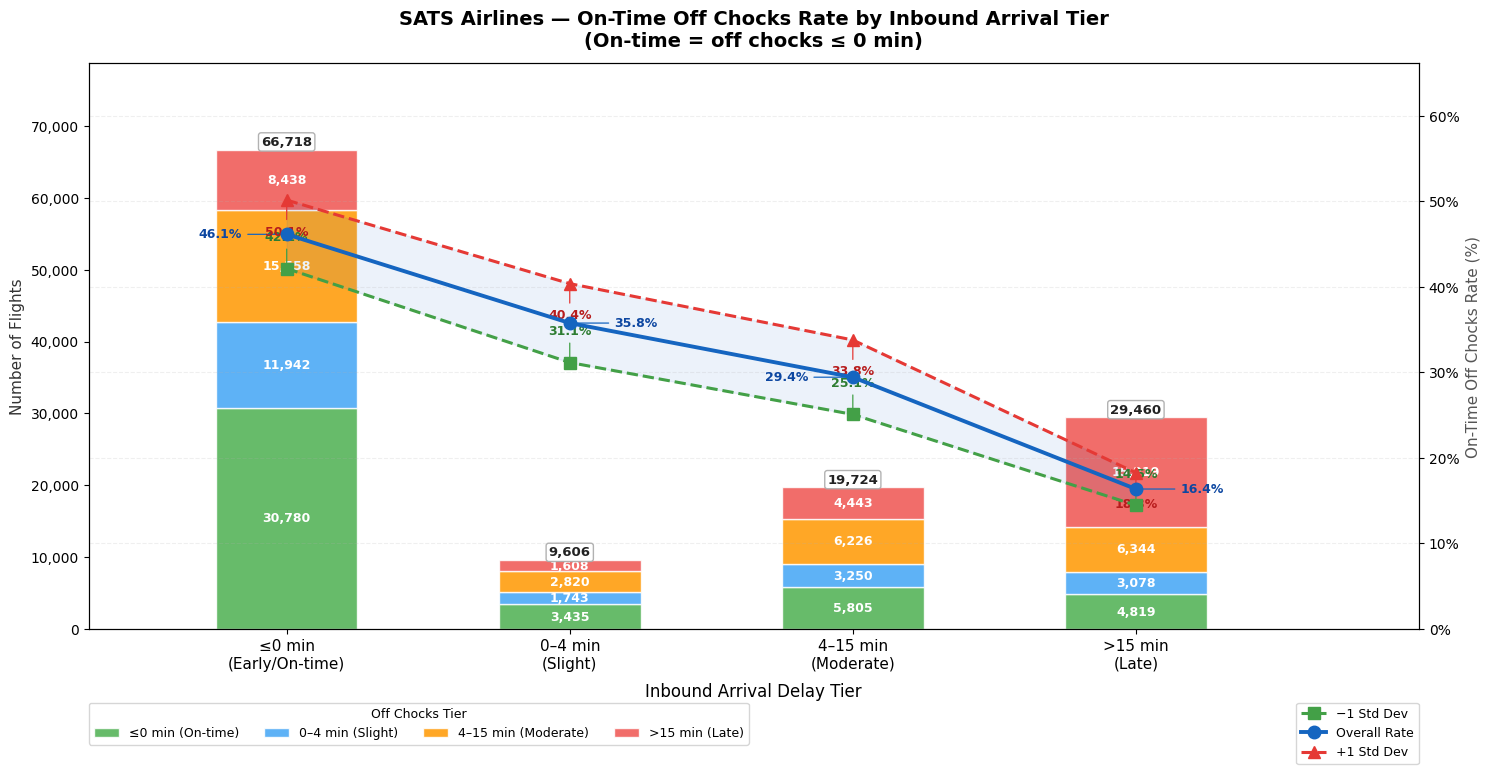

In [8]:
# ── On-Time Off Chocks Rate by Inbound Arrival Tier ─────────────────────
labels = ['≤0 min\n(Early/On-time)', '0–4 min\n(Slight)', '4–15 min\n(Moderate)', '>15 min\n(Late)']
monthly_rates = (
    df_sats_arr.groupby(['arrival_tier','month_str'])
    .apply(lambda x: x['dep_ontime'].mean()*100)
    .reset_index(name='rate')
)
rates = tbl['ontime_rate'].values
std_r = monthly_rates.groupby('arrival_tier')['rate'].std().reindex(tier_order).values
lo_r  = rates - std_r
hi_r  = rates + std_r

def _dep_tier(d):
    if pd.isna(d): return None
    if d <= 0:  return 't1'
    if d <= 4:  return 't2'
    if d <= 15: return 't3'
    return      't4'

_dkeys   = ['t1','t2','t3','t4']
_dcolors = ['#4CAF50','#42A5F5','#FF9800','#EF5350']
_dlabels = ['≤0 min (On-time)','0–4 min (Slight)','4–15 min (Moderate)','>15 min (Late)']

_tmp = df_sats_arr.copy()
_tmp['_dt'] = _tmp['dep_delay_mins'].apply(_dep_tier)
_dep_cnt = (_tmp.groupby(['arrival_tier','_dt']).size().reset_index(name='n')
            .pivot(index='arrival_tier', columns='_dt', values='n')
            .reindex(index=tier_order, columns=_dkeys).fillna(0))

x = list(range(4))
fig, ax_bar = plt.subplots(figsize=(15, 9))
ax_line = ax_bar.twinx()

bot = np.zeros(4)
for dk, dc, dl in zip(_dkeys, _dcolors, _dlabels):
    vals = _dep_cnt[dk].values
    ax_bar.bar(x, vals, 0.5, bottom=bot, color=dc, edgecolor='white', alpha=0.85, label=dl, zorder=2)
    for i, (v, b) in enumerate(zip(vals, bot)):
        if v > 1500:
            ax_bar.text(i, b+v*0.5, f'{int(v):,}', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold', zorder=3)
    bot += vals
totals = _dep_cnt.sum(axis=1).values
for i, tot in enumerate(totals):
    ax_bar.text(i, tot+150, f'{int(tot):,}', ha='center', va='bottom', fontsize=9.5,
                color='#222', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.9), zorder=4)

ax_bar.set_xlim(-0.7, 4.0)
ax_bar.set_ylim(0, totals.max()*1.18)
ax_bar.set_ylabel('Number of Flights', fontsize=11, color='#333')
ax_bar.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels, fontsize=11)
ax_bar.set_xlabel('Inbound Arrival Delay Tier', fontsize=12, labelpad=8)
ax_bar.set_title('SATS Airlines — On-Time Off Chocks Rate by Inbound Arrival Tier\n'
                 '(On-time = off chocks ≤ 0 min)', fontsize=14, fontweight='bold', pad=12)

ax_line.plot(x, lo_r,  color='#43A047', marker='s', lw=2.2, ms=8, ls='--', label='−1 Std Dev', zorder=5)
ax_line.plot(x, rates, color='#1565C0', marker='o', lw=2.8, ms=9,          label='Overall Rate', zorder=5)
ax_line.plot(x, hi_r,  color='#E53935', marker='^', lw=2.2, ms=8, ls='--', label='+1 Std Dev',  zorder=5)
ax_line.fill_between(x, lo_r, hi_r, alpha=0.08, color='#1565C0', zorder=1)
for i in range(4):
    ax_line.annotate(f'{lo_r[i]:.1f}%', xy=(i,lo_r[i]), xytext=(0,18), textcoords='offset points',
                     fontsize=9, color='#2E7D32', fontweight='bold', ha='center', va='bottom',
                     arrowprops=dict(arrowstyle='-', color='#43A047', lw=0.9))
    xo = 32 if i in (1,3) else -32; ha = 'left' if i in (1,3) else 'right'
    ax_line.annotate(f'{rates[i]:.1f}%', xy=(i,rates[i]), xytext=(xo,0), textcoords='offset points',
                     fontsize=9, color='#0D47A1', fontweight='bold', ha=ha, va='center',
                     arrowprops=dict(arrowstyle='-', color='#1565C0', lw=0.9))
    ax_line.annotate(f'{hi_r[i]:.1f}%', xy=(i,hi_r[i]), xytext=(0,-18), textcoords='offset points',
                     fontsize=9, color='#B71C1C', fontweight='bold', ha='center', va='top',
                     arrowprops=dict(arrowstyle='-', color='#E53935', lw=0.9))
ax_line.set_ylim(max(0, lo_r.min()-16), hi_r.max()+16)
ax_line.set_ylabel('On-Time Off Chocks Rate (%)', fontsize=11, color='#555')
ax_line.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax_line.grid(axis='y', ls='--', alpha=0.2)

# Legends placed below axes to avoid overlap
ax_bar.legend(fontsize=9, title='Off Chocks Tier', title_fontsize=9,
              loc='upper left', bbox_to_anchor=(0.0, -0.13), ncol=4, borderaxespad=0)
ax_line.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.0, -0.13), borderaxespad=0)
plt.tight_layout(rect=[0, 0.11, 1, 1])
plt.show()

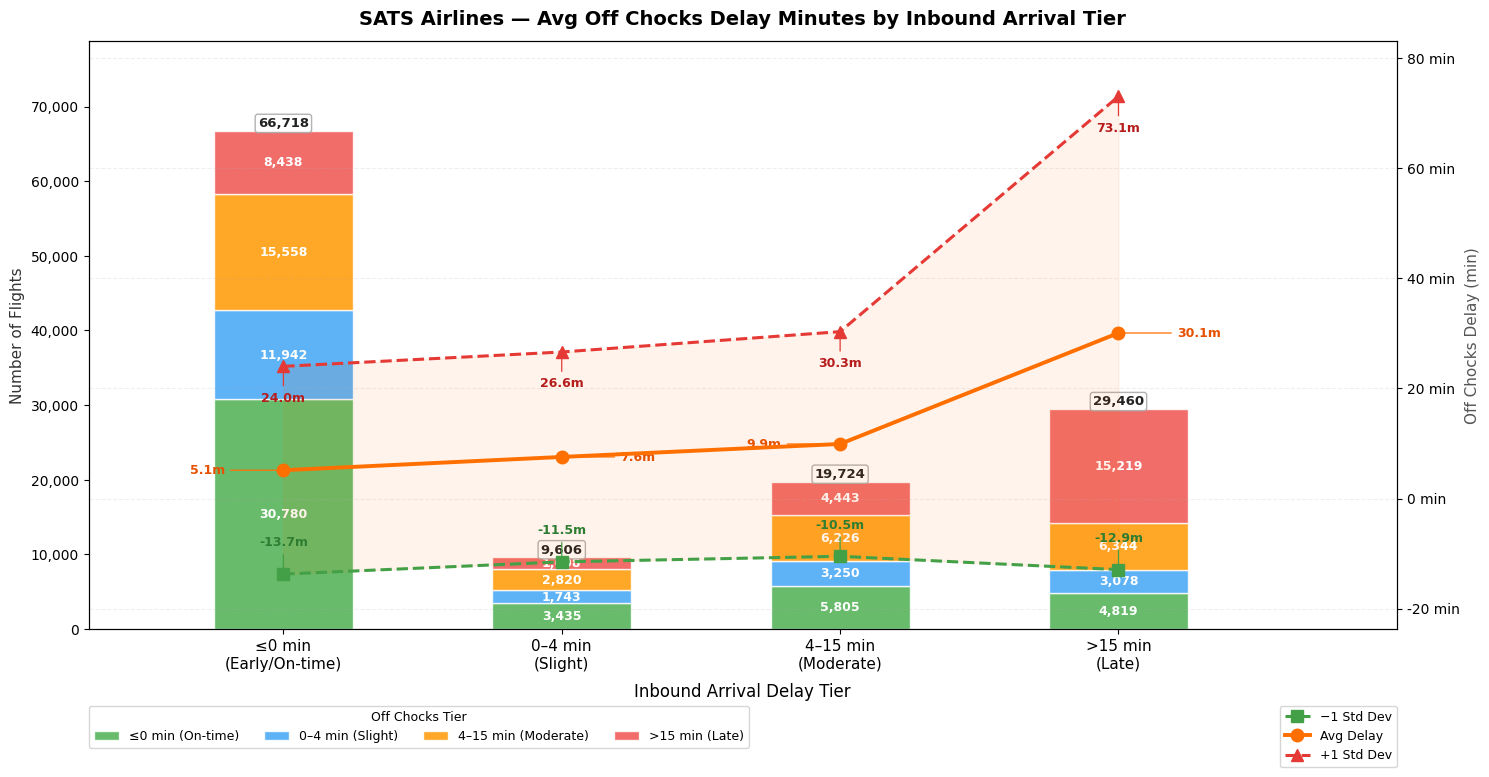

In [9]:
# ── Avg Off Chocks Delay Minutes by Arrival Tier ─────────────────────────
avg_dep = df_sats_arr.groupby('arrival_tier')['dep_delay_mins'].mean().reindex(tier_order).values
std_dep = df_sats_arr.groupby('arrival_tier')['dep_delay_mins'].std().reindex(tier_order).values
lo_dep  = avg_dep - std_dep
hi_dep  = avg_dep + std_dep

fig, ax_bar = plt.subplots(figsize=(15, 9))
ax_line = ax_bar.twinx()

bot = np.zeros(4)
for dk, dc, dl in zip(_dkeys, _dcolors, _dlabels):
    vals = _dep_cnt[dk].values
    ax_bar.bar(x, vals, 0.5, bottom=bot, color=dc, edgecolor='white', alpha=0.85, label=dl, zorder=2)
    for i,(v,b) in enumerate(zip(vals,bot)):
        if v > 1500:
            ax_bar.text(i, b+v*0.5, f'{int(v):,}', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold', zorder=3)
    bot += vals
for i, tot in enumerate(totals):
    ax_bar.text(i, tot+150, f'{int(tot):,}', ha='center', va='bottom', fontsize=9.5,
                color='#222', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.9), zorder=4)
ax_bar.set_xlim(-0.7, 4.0)
ax_bar.set_ylim(0, totals.max()*1.18)
ax_bar.set_ylabel('Number of Flights', fontsize=11, color='#333')
ax_bar.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels, fontsize=11)
ax_bar.set_xlabel('Inbound Arrival Delay Tier', fontsize=12, labelpad=8)
ax_bar.set_title('SATS Airlines — Avg Off Chocks Delay Minutes by Inbound Arrival Tier',
                 fontsize=14, fontweight='bold', pad=12)

ax_line.plot(x, lo_dep,  color='#43A047', marker='s', lw=2.2, ms=8, ls='--', label='−1 Std Dev', zorder=5)
ax_line.plot(x, avg_dep, color='#FF6F00', marker='o', lw=2.8, ms=9,          label='Avg Delay',   zorder=5)
ax_line.plot(x, hi_dep,  color='#E53935', marker='^', lw=2.2, ms=8, ls='--', label='+1 Std Dev',  zorder=5)
ax_line.fill_between(x, lo_dep, hi_dep, alpha=0.08, color='#FF6F00', zorder=1)
for i in range(4):
    ax_line.annotate(f'{lo_dep[i]:.1f}m', xy=(i,lo_dep[i]), xytext=(0,18), textcoords='offset points',
                     fontsize=9, color='#2E7D32', fontweight='bold', ha='center', va='bottom',
                     arrowprops=dict(arrowstyle='-', color='#43A047', lw=0.9))
    xo = 42 if i in (1,3) else -42; ha = 'left' if i in (1,3) else 'right'
    ax_line.annotate(f'{avg_dep[i]:.1f}m', xy=(i,avg_dep[i]), xytext=(xo,0), textcoords='offset points',
                     fontsize=9, color='#E65100', fontweight='bold', ha=ha, va='center',
                     arrowprops=dict(arrowstyle='-', color='#FF6F00', lw=0.9))
    ax_line.annotate(f'{hi_dep[i]:.1f}m', xy=(i,hi_dep[i]), xytext=(0,-18), textcoords='offset points',
                     fontsize=9, color='#B71C1C', fontweight='bold', ha='center', va='top',
                     arrowprops=dict(arrowstyle='-', color='#E53935', lw=0.9))
ax_line.set_ylim(lo_dep.min()-10, hi_dep.max()+10)
ax_line.set_ylabel('Off Chocks Delay (min)', fontsize=11, color='#555')
ax_line.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f} min'))
ax_line.grid(axis='y', ls='--', alpha=0.2)

# Legends placed below axes to avoid overlap
ax_bar.legend(fontsize=9, title='Off Chocks Tier', title_fontsize=9,
              loc='upper left', bbox_to_anchor=(0.0, -0.13), ncol=4, borderaxespad=0)
ax_line.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.0, -0.13), borderaxespad=0)
plt.tight_layout(rect=[0, 0.11, 1, 1])
plt.show()

### How to Read the Box Plot Charts

Each box below represents **one month of flight data** for a specific carrier group.

| Element | Meaning |
|---------|--------|
| **Box** (shaded area) | Middle 50% of flights — from the 25th to 75th percentile (IQR) |
| **Orange line** inside box | Median — half of flights are above this, half below |
| **μ = X** label | Mean (average) — pulled higher than median when there are a few very long delays |
| **Dashed whiskers** | Extend to 1.5× the IQR beyond the box edges |
| **Faint dots** beyond whiskers | Outliers — individual flights with unusually large delays |
| **Dotted horizontal line** | Reference threshold (5 min for off chocks) |

A wide box means **high variability** in that month — some flights pushed back quickly, others waited a long time. A median below zero means more than half of flights pushed back ahead of schedule.

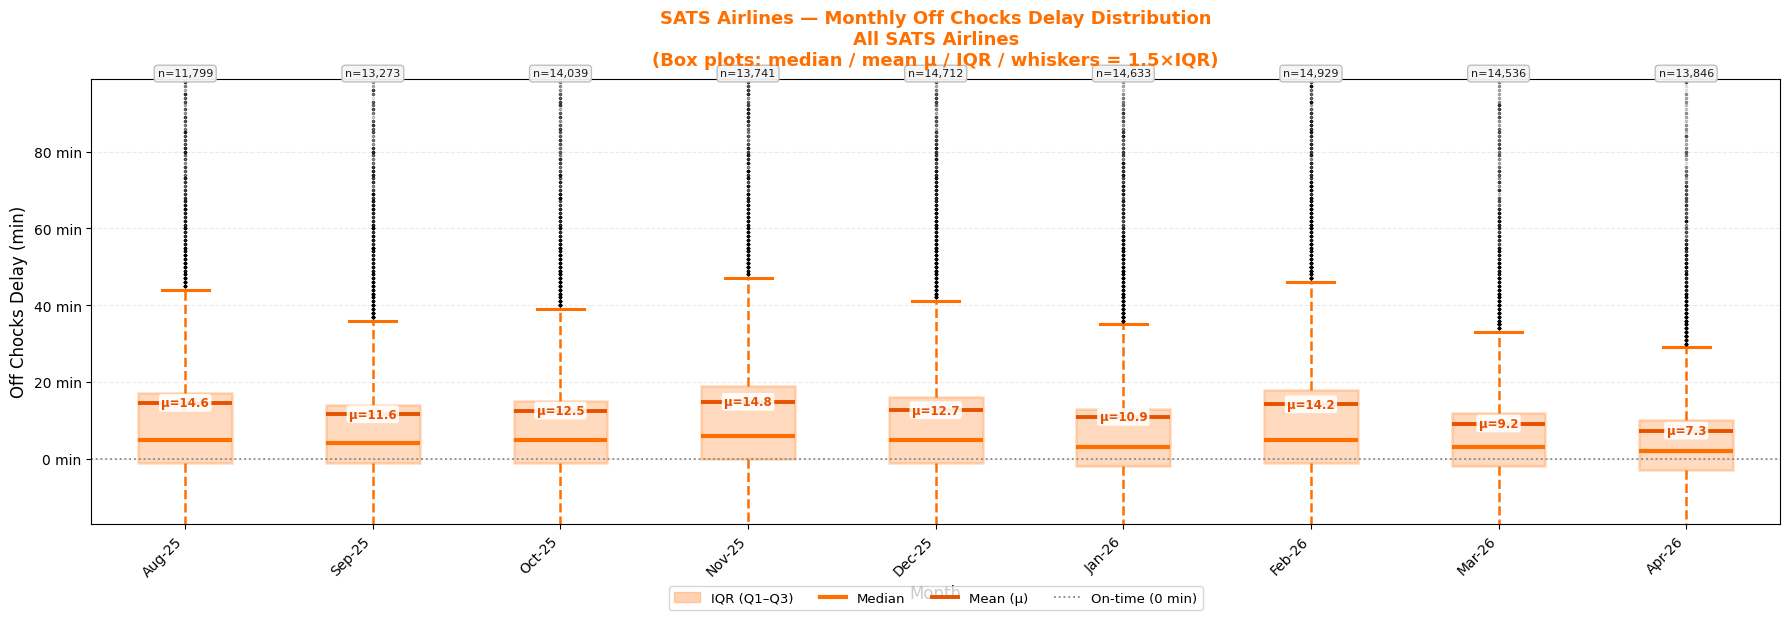

In [10]:
# ── Monthly Off Chocks Delay — Box Plot: All SATS Airlines ──────────────
_months  = sorted(df_sats_arr['month_str'].unique())
_mlabels = [pd.Period(m,'M').to_timestamp().strftime('%b-%y') for m in _months]
_accent  = '#FF6F00'
_data    = [df_sats_arr.loc[df_sats_arr['month_str']==m,'dep_delay_mins'].dropna().values for m in _months]
_n_list  = [len(d) for d in _data]

_all_v = np.concatenate(_data)
fig, ax = plt.subplots(figsize=(18, 7))
ax.set_ylim(np.percentile(_all_v,2)-5, np.percentile(_all_v,97)+20)
ax.boxplot(_data, positions=list(range(len(_months))), widths=0.5,
           patch_artist=True, showfliers=True,
           flierprops=dict(marker='.', color=_accent, alpha=0.15, markersize=3),
           medianprops=dict(color='#FF6F00', linewidth=3.0),
           boxprops=dict(facecolor=_accent, alpha=0.25, linewidth=1.8, edgecolor=_accent),
           whiskerprops=dict(color=_accent, linewidth=1.8, linestyle='--'),
           capprops=dict(color=_accent, linewidth=2.2),
           meanline=True, showmeans=True,
           meanprops=dict(color='#E65100', linewidth=2.8, linestyle='-'))
ax.axhline(0, color='#888', linestyle=':', linewidth=1.3, label='On-time threshold (0 min)')
for i, d in enumerate(_data):
    if len(d)==0: continue
    ax.annotate(f'μ={np.mean(d):.1f}', xy=(i,np.mean(d)), xytext=(0,0),
                textcoords='offset points', ha='center', va='center', fontsize=8.5,
                color='#E65100', fontweight='bold', zorder=6,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.9))
_y_top = ax.get_ylim()[1]
for i, n in enumerate(_n_list):
    ax.annotate(f'n={n:,}', xy=(i,_y_top), ha='center', va='bottom', fontsize=8, color='#1a1a1a',
                bbox=dict(boxstyle='round,pad=0.3', fc='#F5F5F5', ec='#BDBDBD', alpha=0.95))
ax.set_xticks(range(len(_months)))
ax.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Month', fontsize=12, labelpad=4)
ax.set_ylabel('Off Chocks Delay (min)', fontsize=12)
ax.set_title('SATS Airlines — Monthly Off Chocks Delay Distribution\nAll SATS Airlines\n'
             '(Box plots: median / mean μ / IQR / whiskers = 1.5×IQR)',
             fontsize=13, fontweight='bold', pad=10, color=_accent)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f} min'))
ax.grid(axis='y', ls='--', alpha=0.25)
ax.legend(handles=[
    Patch(facecolor=_accent, alpha=0.3, edgecolor=_accent, label='IQR (Q1–Q3)'),
    Line2D([0],[0], color='#FF6F00', lw=3.0, label='Median'),
    Line2D([0],[0], color='#E65100', lw=2.8, ls='-', label='Mean (μ)'),
    Line2D([0],[0], color='#888', lw=1.3, ls=':', label='On-time (0 min)'),
], fontsize=9.5, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=4, borderaxespad=0)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

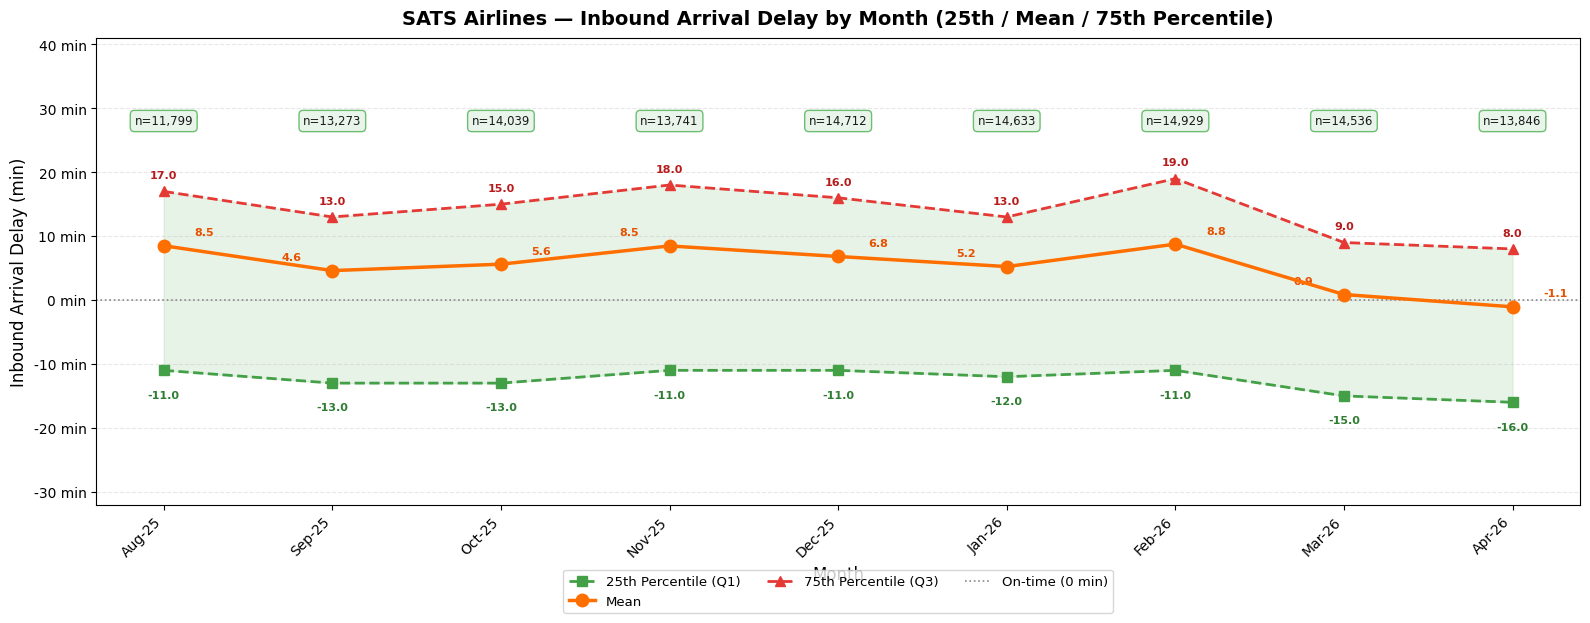

In [11]:
# ── Monthly Inbound Arrival Delay: 25th / Mean / 75th Percentile ─────────
monthly_arr = (
    df_sats_arr.groupby('month_str')['inbound_delay_mins']
    .agg(
        q1    = lambda x: x.quantile(0.25),
        mean  = 'mean',
        q3    = lambda x: x.quantile(0.75),
        count = 'count',
    )
    .reset_index()
    .sort_values('month_str')
    .reset_index(drop=True)
)
monthly_arr = monthly_arr[~monthly_arr['month_str'].str.contains('-06|-07|2026-05')].reset_index(drop=True)

x     = list(range(len(monthly_arr)))
box_y = monthly_arr['q3'].max() + 8

fig, ax = plt.subplots(figsize=(16, 7))

ax.fill_between(x, monthly_arr['q1'], monthly_arr['q3'], alpha=0.12, color='#43A047')
ax.plot(x, monthly_arr['q1'],   color='#43A047', marker='s', lw=2,   ms=7, ls='--', label='25th Percentile (Q1)', zorder=5)
ax.plot(x, monthly_arr['mean'], color='#FF6F00', marker='o', lw=2.5, ms=9,          label='Mean',                zorder=5)
ax.plot(x, monthly_arr['q3'],   color='#E53935', marker='^', lw=2,   ms=7, ls='--', label='75th Percentile (Q3)', zorder=5)
ax.axhline(0, color='#888', linestyle=':', linewidth=1.2, label='On-time (0 min)')

for i, row in monthly_arr.iterrows():
    ax.annotate(f"{row['q1']:.1f}",  xy=(i, row['q1']),  xytext=(0, -14), textcoords='offset points',
                ha='center', va='top',    fontsize=8, color='#2E7D32', fontweight='bold')
    x_off = 22 if i % 2 == 0 else -22
    h_align = 'left' if i % 2 == 0 else 'right'
    ax.annotate(f"{row['mean']:.1f}", xy=(i, row['mean']), xytext=(x_off, 6), textcoords='offset points',
                ha=h_align, va='bottom', fontsize=8, color='#E65100', fontweight='bold')
    ax.annotate(f"{row['q3']:.1f}",  xy=(i, row['q3']),  xytext=(0, 8),  textcoords='offset points',
                ha='center', va='bottom', fontsize=8, color='#B71C1C', fontweight='bold')

for i, row in monthly_arr.iterrows():
    ax.annotate(
        f"n={int(row['count']):,}",
        xy=(i, box_y), ha='center', va='bottom', fontsize=8.5, color='#1a1a1a',
        bbox=dict(boxstyle='round,pad=0.35', fc='#E8F5E9', ec='#66BB6A', alpha=0.95)
    )

ax.set_ylim(monthly_arr['q1'].min() - 16, box_y + 14)
ax.set_xticks(x)
ax.set_xticklabels([pd.Period(m,'M').to_timestamp().strftime('%b-%y') for m in monthly_arr['month_str']], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Inbound Arrival Delay (min)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_title(
    'SATS Airlines — Inbound Arrival Delay by Month (25th / Mean / 75th Percentile)',
    fontsize=14, fontweight='bold', pad=10
)
ax.legend(fontsize=9.5, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, borderaxespad=0)
ax.grid(axis='y', ls='--', alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.0f} min'))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

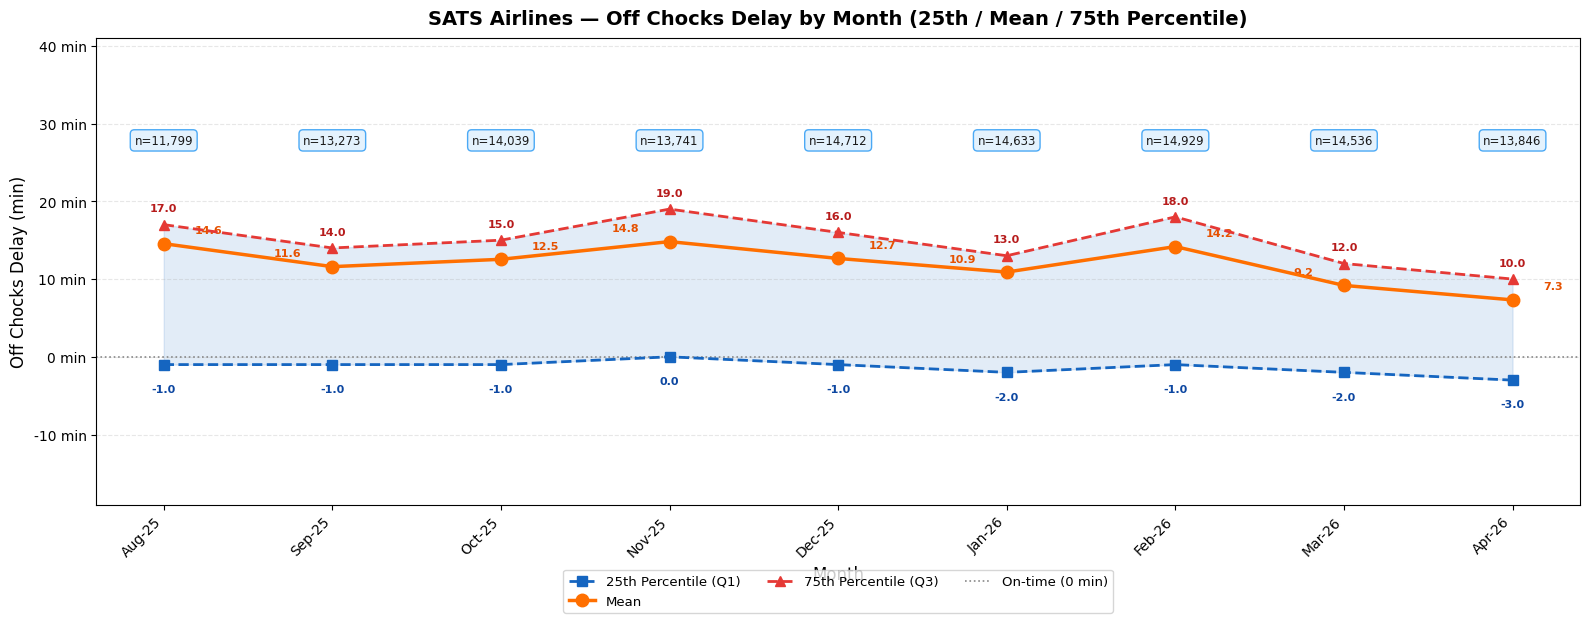

In [12]:
# ── Monthly Off Chocks Delay: 25th / Mean / 75th Percentile ──────────────
monthly_dep = (
    df_sats_arr.groupby('month_str')['dep_delay_mins']
    .agg(
        q1    = lambda x: x.quantile(0.25),
        mean  = 'mean',
        q3    = lambda x: x.quantile(0.75),
        count = 'count',
    )
    .reset_index()
    .sort_values('month_str')
    .reset_index(drop=True)
)
monthly_dep = monthly_dep[~monthly_dep['month_str'].str.contains('-06|-07|2026-05')].reset_index(drop=True)

x     = list(range(len(monthly_dep)))
box_y = monthly_dep['q3'].max() + 8

fig, ax = plt.subplots(figsize=(16, 7))

ax.fill_between(x, monthly_dep['q1'], monthly_dep['q3'], alpha=0.12, color='#1565C0')
ax.plot(x, monthly_dep['q1'],   color='#1565C0', marker='s', lw=2,   ms=7, ls='--', label='25th Percentile (Q1)', zorder=5)
ax.plot(x, monthly_dep['mean'], color='#FF6F00', marker='o', lw=2.5, ms=9,          label='Mean',                zorder=5)
ax.plot(x, monthly_dep['q3'],   color='#E53935', marker='^', lw=2,   ms=7, ls='--', label='75th Percentile (Q3)', zorder=5)
ax.axhline(0, color='#888', linestyle=':', linewidth=1.2, label='On-time (0 min)')

for i, row in monthly_dep.iterrows():
    ax.annotate(f"{row['q1']:.1f}",  xy=(i, row['q1']),  xytext=(0, -14), textcoords='offset points',
                ha='center', va='top',    fontsize=8, color='#0D47A1', fontweight='bold')
    x_off = 22 if i % 2 == 0 else -22
    h_align = 'left' if i % 2 == 0 else 'right'
    ax.annotate(f"{row['mean']:.1f}", xy=(i, row['mean']), xytext=(x_off, 6), textcoords='offset points',
                ha=h_align, va='bottom', fontsize=8, color='#E65100', fontweight='bold')
    ax.annotate(f"{row['q3']:.1f}",  xy=(i, row['q3']),  xytext=(0, 8),  textcoords='offset points',
                ha='center', va='bottom', fontsize=8, color='#B71C1C', fontweight='bold')

for i, row in monthly_dep.iterrows():
    ax.annotate(
        f"n={int(row['count']):,}",
        xy=(i, box_y), ha='center', va='bottom', fontsize=8.5, color='#1a1a1a',
        bbox=dict(boxstyle='round,pad=0.35', fc='#E3F2FD', ec='#42A5F5', alpha=0.95)
    )

ax.set_ylim(monthly_dep['q1'].min() - 16, box_y + 14)
ax.set_xticks(x)
ax.set_xticklabels([pd.Period(m,'M').to_timestamp().strftime('%b-%y') for m in monthly_dep['month_str']], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Off Chocks Delay (min)', fontsize=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_title(
    'SATS Airlines — Off Chocks Delay by Month (25th / Mean / 75th Percentile)',
    fontsize=14, fontweight='bold', pad=10
)
ax.legend(fontsize=9.5, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, borderaxespad=0)
ax.grid(axis='y', ls='--', alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.0f} min'))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

------------------------------------------------------------------------------
Arrival Tier                               n  Avg Inbound  Avg Off Chocks    Ratio
------------------------------------------------------------------------------
1 — Early / On-time (≤ 0 min)         66,718       -14.1m           +5.1m     N/A*
2 — Slight delay (0–4 min)             9,606        +2.4m           +7.6m     3.1x
3 — Moderate delay (4–15 min)         19,724        +9.5m           +9.9m     1.0x
4 — Late (> 15 min)                   29,460       +47.1m          +30.1m     0.6x
------------------------------------------------------------------------------
* Ratio not shown for tier 1 — inbound arrives early (negative), departure still late.

Interpretation:
  0–4 min inbound  → avg 2.4 min late inbound,  7.4 min late off chocks  (3.0x amplification)
  4–15 min inbound → avg 9.5 min late inbound,  9.8 min late off chocks  (~1x, delay absorbed)
  >15 min inbound  → avg 47.1 min late inbound, 29.9 mi

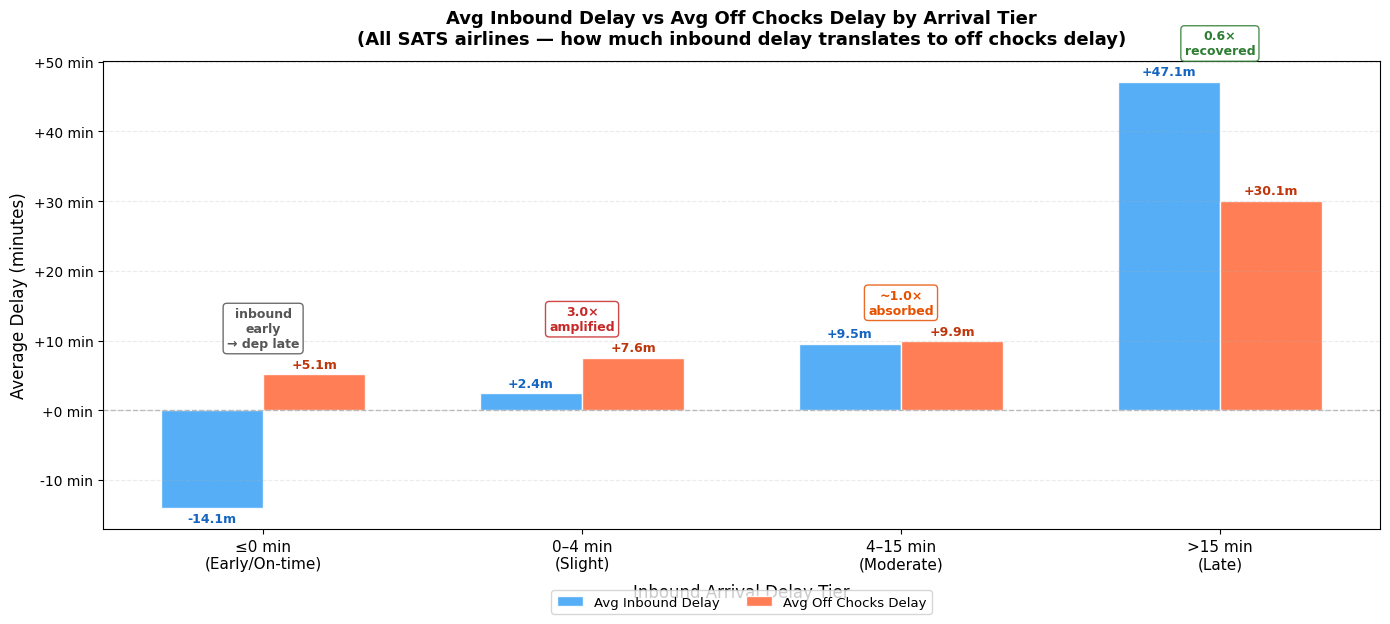

In [13]:
# ── Avg Inbound Delay vs Avg Off Chocks Delay by Arrival Tier ───────────
_tier_order = ['1 — Early / On-time (≤ 0 min)','2 — Slight delay (0–4 min)',
               '3 — Moderate delay (4–15 min)','4 — Late (> 15 min)']
_tier_short = ['≤0 min\n(Early/On-time)','0–4 min\n(Slight)','4–15 min\n(Moderate)','>15 min\n(Late)']

_stats = df_sats_arr.groupby('arrival_tier').agg(
    n           =('dep_delay_mins','count'),
    avg_inbound =('inbound_delay_mins','mean'),
    avg_dep     =('dep_delay_mins','mean'),
    med_inbound =('inbound_delay_mins','median'),
    med_dep     =('dep_delay_mins','median'),
).reindex(_tier_order)

# ── Print table ──────────────────────────────────────────────────────────
print(f'{"-"*78}')
print(f'{"Arrival Tier":<36} {"n":>7}  {"Avg Inbound":>11}  {"Avg Off Chocks":>14}  {"Ratio":>7}')
print(f'{"-"*78}')
for t in _tier_order:
    r = _stats.loc[t]
    if r['avg_inbound'] > 0:
        ratio_str = f'{r["avg_dep"]/r["avg_inbound"]:.1f}x'
    else:
        ratio_str = 'N/A*'
    print(f'{t:<36} {int(r["n"]):>7,}  {r["avg_inbound"]:>+10.1f}m  {r["avg_dep"]:>+13.1f}m  {ratio_str:>7}')
print(f'{"-"*78}')
print('* Ratio not shown for tier 1 — inbound arrives early (negative), departure still late.')
print()
print('Interpretation:')
print('  0–4 min inbound  → avg 2.4 min late inbound,  7.4 min late off chocks  (3.0x amplification)')
print('  4–15 min inbound → avg 9.5 min late inbound,  9.8 min late off chocks  (~1x, delay absorbed)')
print('  >15 min inbound  → avg 47.1 min late inbound, 29.9 min late off chocks (ground teams recover ~37%)')

# ── Chart ────────────────────────────────────────────────────────────────
x = list(range(4))
w = 0.32
avg_inb = _stats['avg_inbound'].values
avg_dep = _stats['avg_dep'].values

fig, ax = plt.subplots(figsize=(14, 7))
bars_inb = ax.bar([i-w/2 for i in x], avg_inb, w, label='Avg Inbound Delay',
                  color='#42A5F5', edgecolor='white', alpha=0.9)
bars_dep = ax.bar([i+w/2 for i in x], avg_dep, w, label='Avg Off Chocks Delay',
                  color='#FF7043', edgecolor='white', alpha=0.9)

for bar, val in zip(bars_inb, avg_inb):
    va = 'bottom' if val >= 0 else 'top'
    yo = 0.5 if val >= 0 else -0.5
    ax.text(bar.get_x()+bar.get_width()/2, val+yo, f'{val:+.1f}m',
            ha='center', va=va, fontsize=9, color='#1565C0', fontweight='bold')
for bar, val in zip(bars_dep, avg_dep):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:+.1f}m',
            ha='center', va='bottom', fontsize=9, color='#BF360C', fontweight='bold')

# Ratio annotations for tiers 2-4
ratio_labels = ['inbound\nearly\n→ dep late', '3.0×\namplified', '~1.0×\nabsorbed', '0.6×\nrecovered']
ratio_colors = ['#555','#C62828','#E65100','#2E7D32']
for i, (lbl, col) in enumerate(zip(ratio_labels, ratio_colors)):
    ax.text(i, max(avg_inb[i], avg_dep[i]) + 3.5, lbl, ha='center', va='bottom',
            fontsize=9, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=col, alpha=0.85))

ax.axhline(0, color='#888', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(_tier_short, fontsize=11)
ax.set_xlabel('Inbound Arrival Delay Tier', fontsize=12, labelpad=8)
ax.set_ylabel('Average Delay (minutes)', fontsize=12)
ax.set_title('Avg Inbound Delay vs Avg Off Chocks Delay by Arrival Tier\n'
             '(All SATS airlines — how much inbound delay translates to off chocks delay)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9.5, loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=2, borderaxespad=0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:+.0f} min'))
ax.grid(axis='y', ls='--', alpha=0.25)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

---
## 5. Carrier Group Analysis: SQ & TR vs All SATS vs Excl. SQ & TR

**Singapore Airlines (SQ) and Scoot (TR)** are Singapore's home-based carriers. Unlike foreign carriers, their crews, maintenance teams, and operations centres are locally based, giving them a structural advantage in recovering from turnaround delays.

The three charts below show the same analysis split into three carrier groups:

| Group | Flights | Share |
|-------|---------|-------|
| SQ & TR only (home carriers) | 71,198 | 56.7% |
| All SATS airlines | 125,508 | 100% |
| All SATS excl. SQ & TR | 54,310 | 43.3% |

Each chart contains three panels stacked vertically:
1. **Line chart** — monthly on-time rate per arrival tier
2. **Stacked bar** — flight volume per tier per month
3. **Heatmap** — rate and count in a single colour-coded grid (green = good, red = poor)

**Read across charts**, not just within one — the gap between SQ & TR (first chart) and Excl. SQ & TR (third chart) is the clearest signal of the home-base effect.

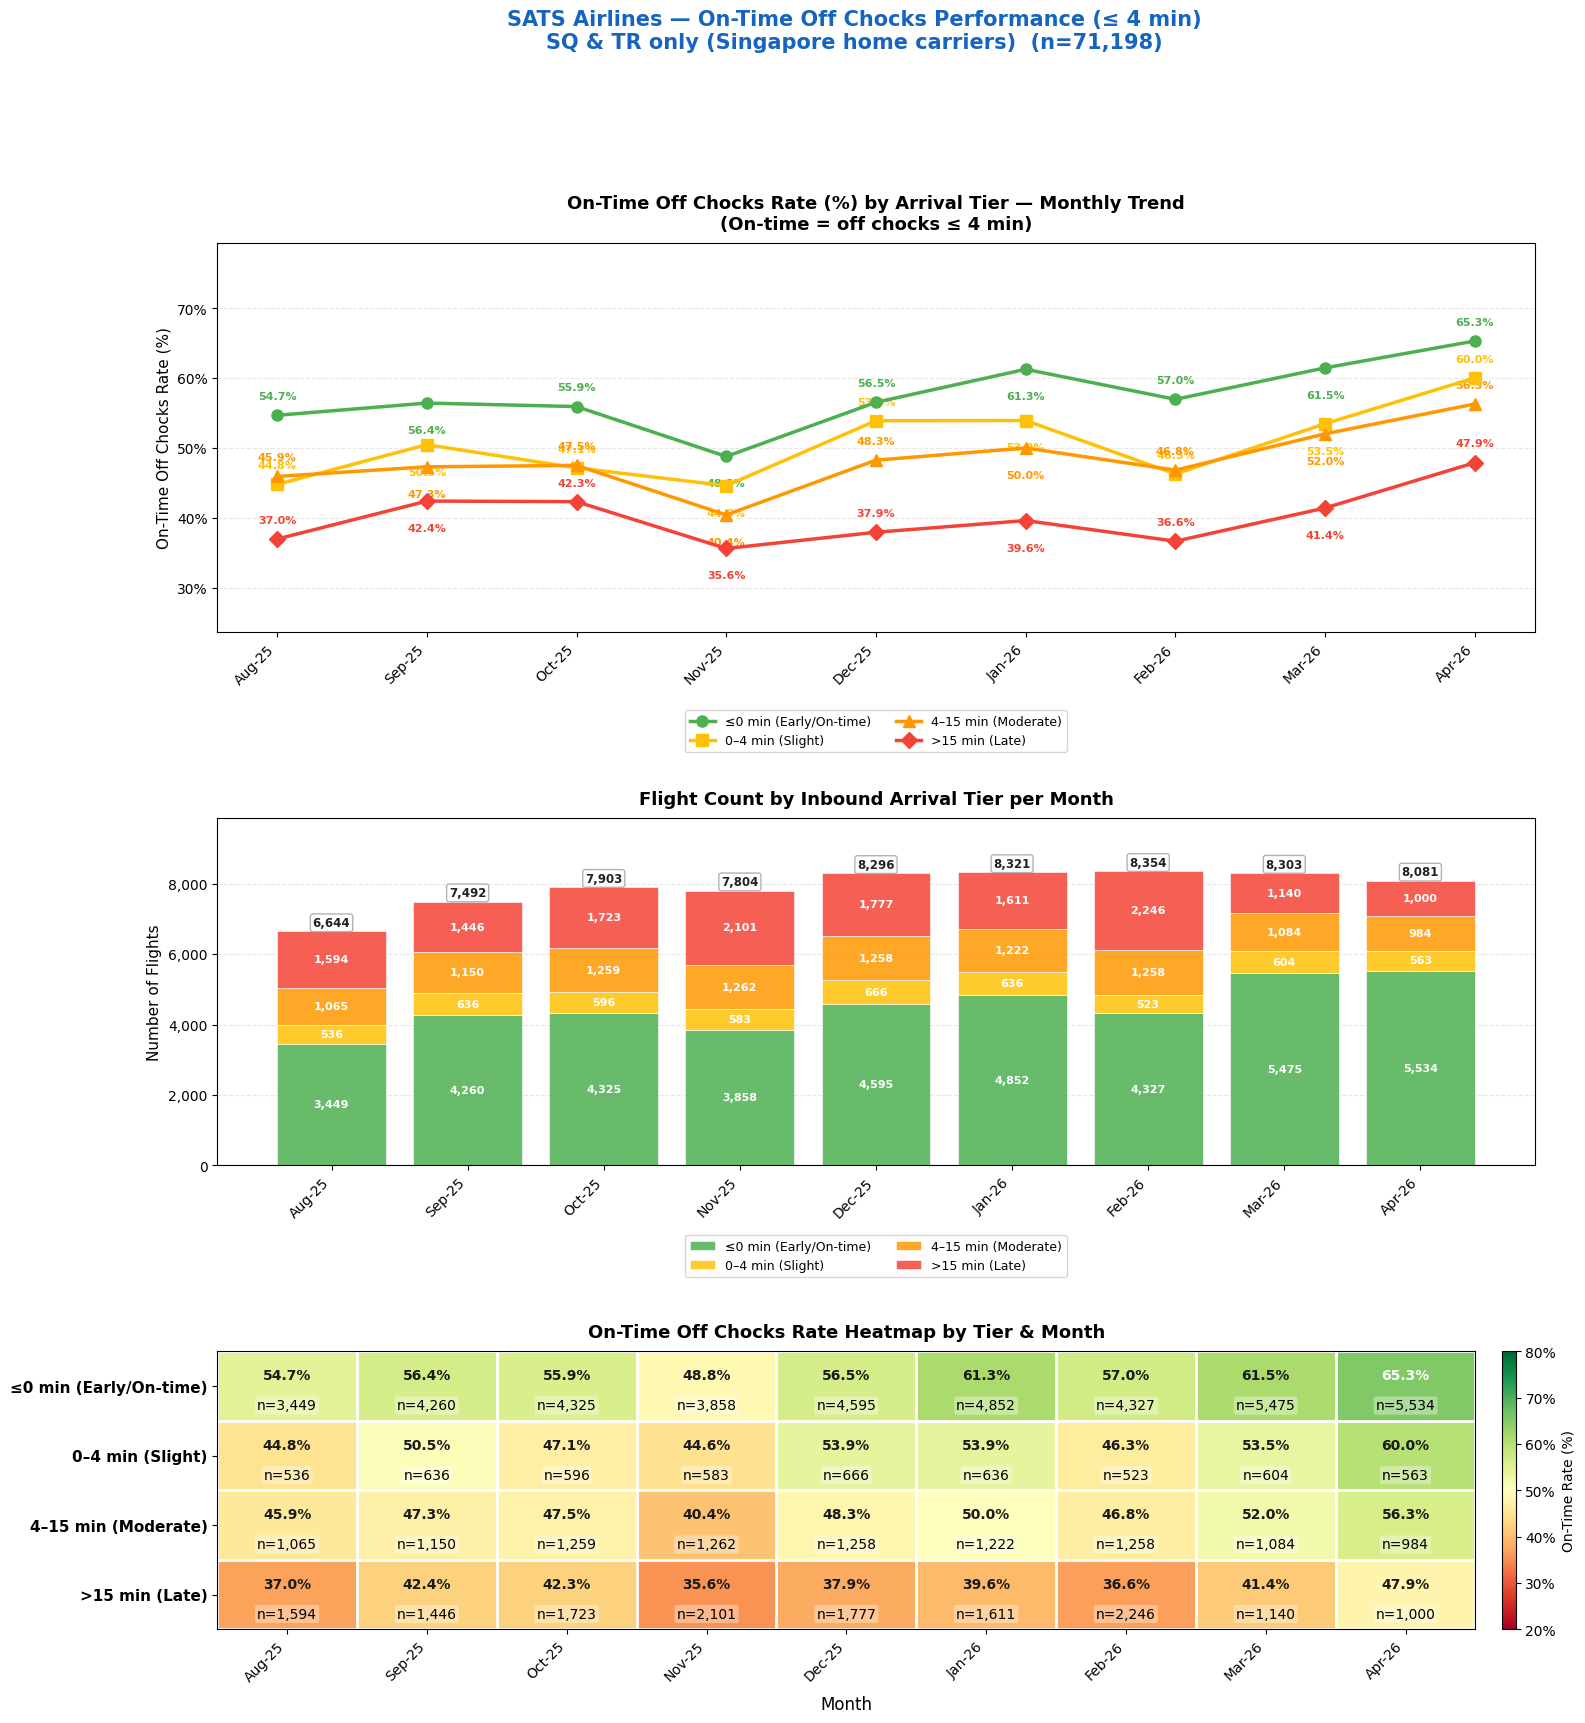

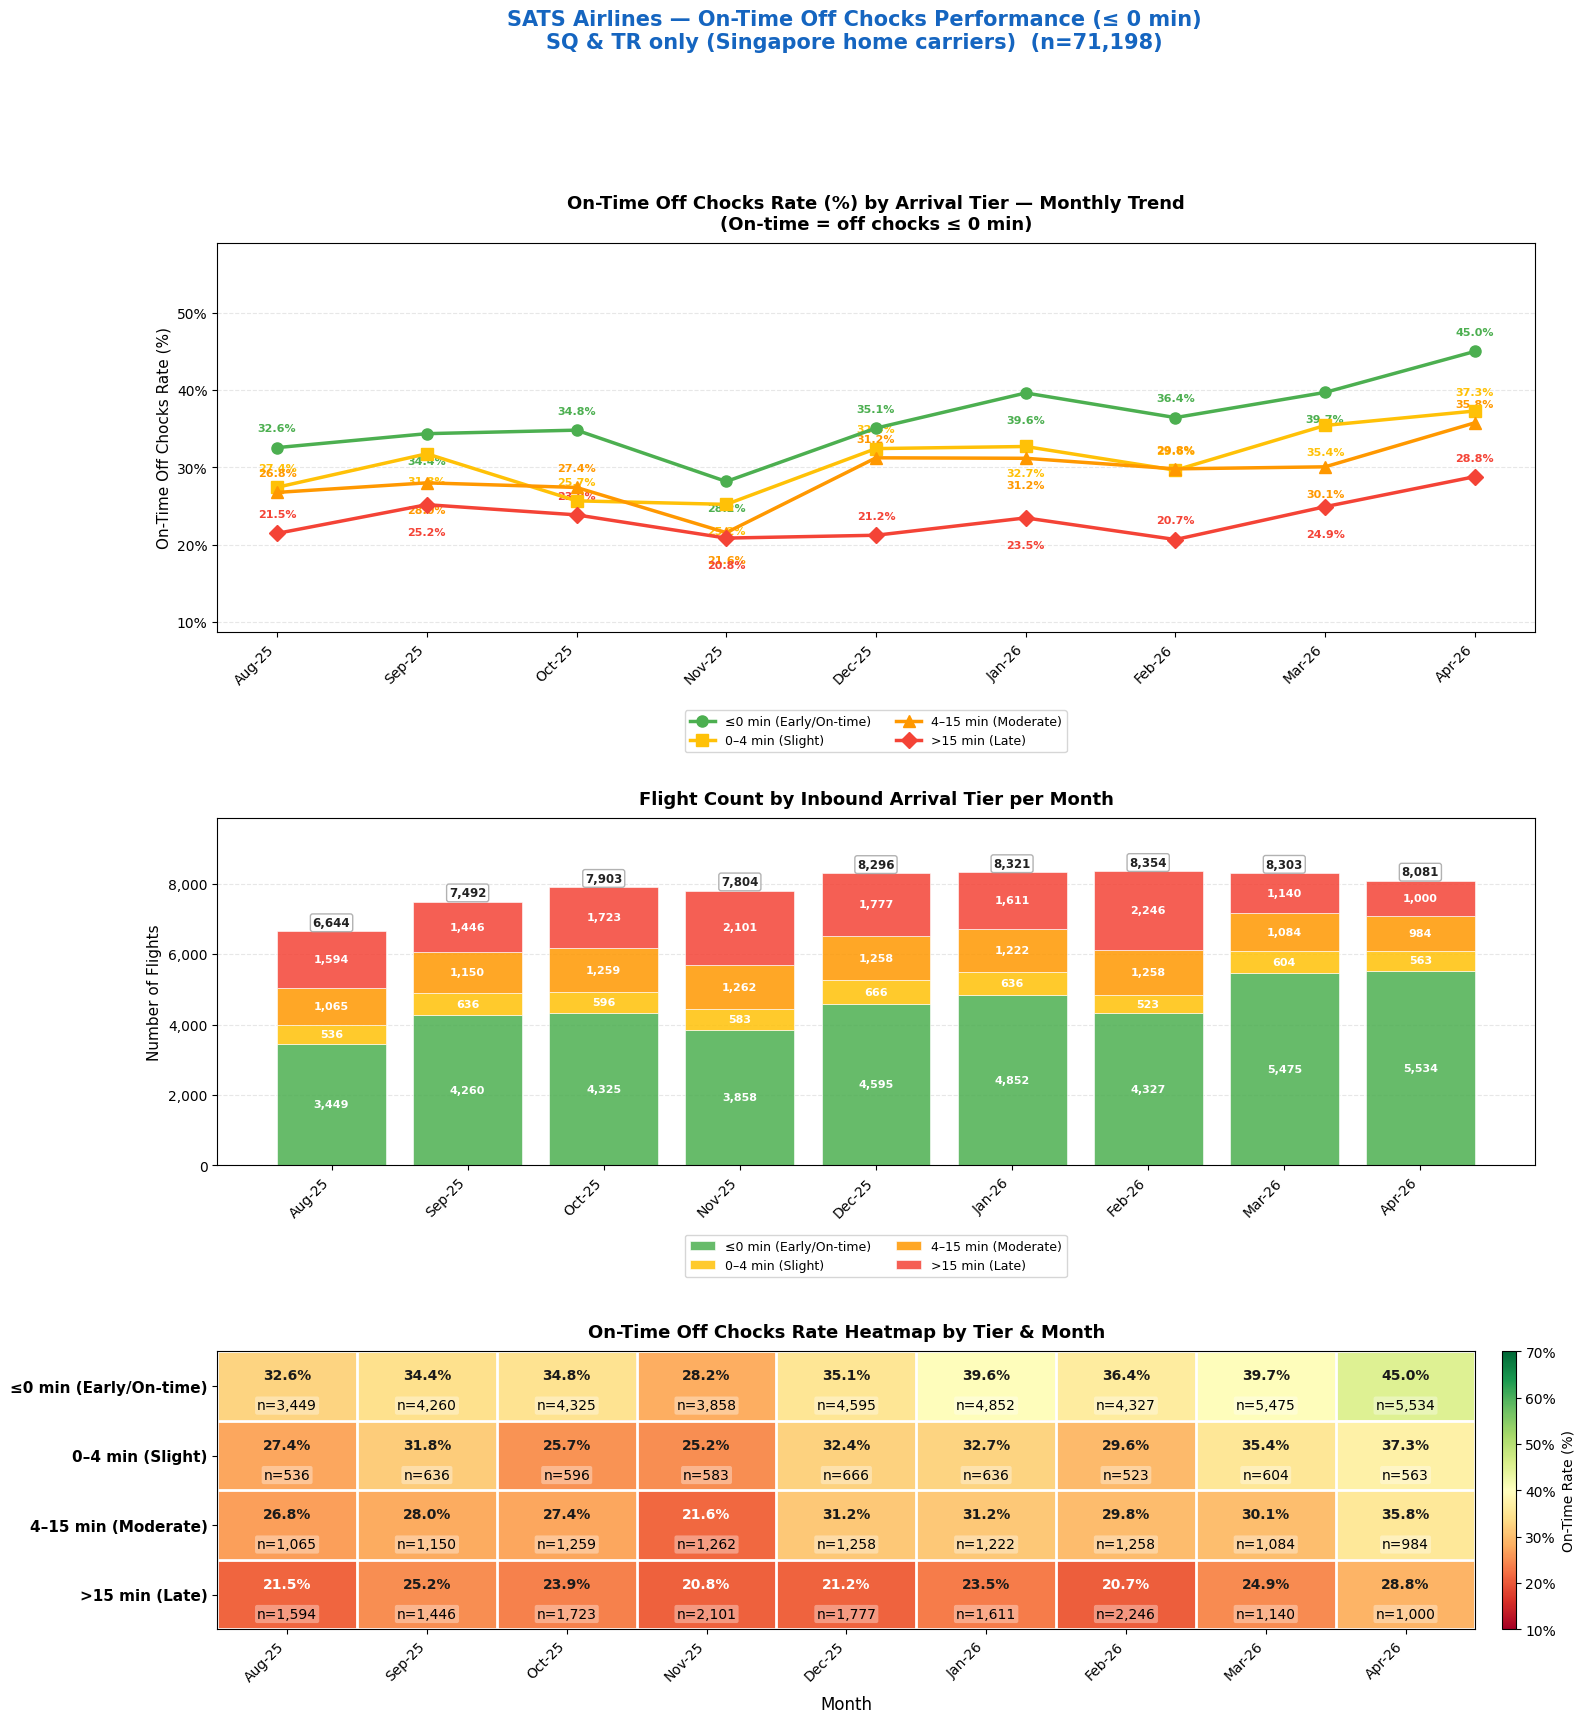

In [14]:
# ── On-Time Off Chocks Performance: SQ & TR only (Singapore home carriers) ─────────────────────
# Shows both thresholds: ≤ 4 min (industry operational) and ≤ 0 min (strict)
_tier_labels  = ['≤0 min (Early/On-time)', '0–4 min (Slight)', '4–15 min (Moderate)', '>15 min (Late)']
_tier_colors  = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
_tier_markers = ['o', 's', '^', 'D']

def _arr_tier_lbl(d):
    if d <= 0:  return '≤0 min (Early/On-time)'
    if d <= 4:  return '0–4 min (Slight)'
    if d <= 15: return '4–15 min (Moderate)'
    return             '>15 min (Late)'

_df_base = df_sats_arr[df_sats_arr['carrier'].isin(HOME)].copy()
_df_base['tier_label'] = _df_base['inbound_delay_mins'].apply(_arr_tier_lbl)

def _draw_combined(df_g, threshold, vmin, vmax, accent='#1565C0'):
    _df = df_g.copy()
    _df['dep_ontime'] = (_df['dep_delay_mins'] <= threshold).astype(int)
    _months  = sorted(_df['month_str'].unique())
    _mlabels = [pd.Period(m,'M').to_timestamp().strftime('%b-%y') for m in _months]
    x        = list(range(len(_months)))
    _grp     = _df.groupby(['tier_label','month_str'])
    _rate_df = _grp['dep_ontime'].mean().unstack('month_str').reindex(index=_tier_labels)[_months] * 100
    _cnt_df  = _grp['dep_ontime'].count().unstack('month_str').reindex(index=_tier_labels)[_months]

    fig = plt.figure(figsize=(17, 18))
    gs  = fig.add_gridspec(3, 1, height_ratios=[2.8, 2.5, 2], hspace=0.55)
    ax_line = fig.add_subplot(gs[0])
    ax_bar  = fig.add_subplot(gs[1])
    ax_heat = fig.add_subplot(gs[2])

    for tier, color, marker in zip(_tier_labels, _tier_colors, _tier_markers):
        vals = _rate_df.loc[tier].values
        ax_line.plot(x, vals, color=color, marker=marker, lw=2.5, ms=8, label=tier, zorder=5)
        for i, v in enumerate(vals):
            yo = 10 if i % 2 == 0 else -16; va = 'bottom' if i % 2 == 0 else 'top'
            ax_line.annotate(f'{v:.1f}%', xy=(i,v), xytext=(0,yo), textcoords='offset points',
                             ha='center', va=va, fontsize=8, color=color, fontweight='bold')
    ax_line.set_xticks(x); ax_line.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
    ax_line.set_ylabel('On-Time Off Chocks Rate (%)', fontsize=11)
    ax_line.set_title(f'On-Time Off Chocks Rate (%) by Arrival Tier — Monthly Trend\n'
                      f'(On-time = off chocks ≤ {threshold} min)', fontsize=13, fontweight='bold', pad=10)
    ax_line.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax_line.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, borderaxespad=0)
    ax_line.grid(axis='y', ls='--', alpha=0.3)
    ax_line.set_ylim(_rate_df.values.min()-12, _rate_df.values.max()+14)

    bot = np.zeros(len(_months))
    for tier, color in zip(_tier_labels, _tier_colors):
        vals = _cnt_df.loc[tier].values
        ax_bar.bar(x, vals, bottom=bot, color=color, edgecolor='white', linewidth=0.5, alpha=0.85, label=tier, zorder=2)
        for i,(v,b) in enumerate(zip(vals,bot)):
            if v > 400:
                ax_bar.text(i, b+v*0.5, f'{int(v):,}', ha='center', va='center', fontsize=8,
                            color='white', fontweight='bold', zorder=3)
        bot += vals
    _totals = _cnt_df.sum(axis=0).values
    for i,tot in enumerate(_totals):
        ax_bar.text(i, tot+60, f'{int(tot):,}', ha='center', va='bottom', fontsize=8.5, color='#222',
                    fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.9), zorder=4)
    ax_bar.set_xticks(x); ax_bar.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
    ax_bar.set_ylabel('Number of Flights', fontsize=11)
    ax_bar.set_title('Flight Count by Inbound Arrival Tier per Month', fontsize=13, fontweight='bold', pad=10)
    ax_bar.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{int(v):,}'))
    ax_bar.set_ylim(0, _totals.max()*1.18)
    ax_bar.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, borderaxespad=0)
    ax_bar.grid(axis='y', ls='--', alpha=0.3, zorder=0)

    im = ax_heat.imshow(_rate_df.values, aspect='auto', cmap='RdYlGn',
                        vmin=vmin, vmax=vmax, interpolation='nearest')
    for r in range(len(_tier_labels)):
        for c in range(len(_months)):
            rate=_rate_df.values[r,c]; n=int(_cnt_df.values[r,c])
            tc = 'white' if rate > vmax*0.78 or rate < vmin+(vmax-vmin)*0.2 else '#1a1a1a'
            ax_heat.text(c, r-0.15, f'{rate:.1f}%', ha='center', va='center',
                         fontsize=10, fontweight='bold', color=tc)
            ax_heat.text(c, r+0.28, f'n={n:,}', ha='center', va='center',
                         bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.35, ec='none'))
    ax_heat.set_xticks(range(len(_months))); ax_heat.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
    ax_heat.set_yticks(range(len(_tier_labels))); ax_heat.set_yticklabels(_tier_labels, fontsize=11, fontweight='bold')
    ax_heat.set_xlabel('Month', fontsize=12, labelpad=8)
    ax_heat.set_title('On-Time Off Chocks Rate Heatmap by Tier & Month', fontsize=13, fontweight='bold', pad=10)
    ax_heat.set_xticks(np.arange(-0.5,len(_months),1), minor=True)
    ax_heat.set_yticks(np.arange(-0.5,len(_tier_labels),1), minor=True)
    ax_heat.grid(which='minor', color='white', linewidth=2); ax_heat.tick_params(which='minor', length=0)
    cbar = plt.colorbar(im, ax=ax_heat, fraction=0.025, pad=0.02)
    cbar.set_label('On-Time Rate (%)', fontsize=10)
    cbar.ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    fig.suptitle(f'SATS Airlines — On-Time Off Chocks Performance (≤ {threshold} min)\nSQ & TR only (Singapore home carriers)  (n={len(df_g):,})',
                 fontsize=15, fontweight='bold', color=accent, y=1.01)
    plt.show()

_draw_combined(_df_base, threshold=4, vmin=20, vmax=80)
_draw_combined(_df_base, threshold=0, vmin=10, vmax=70)

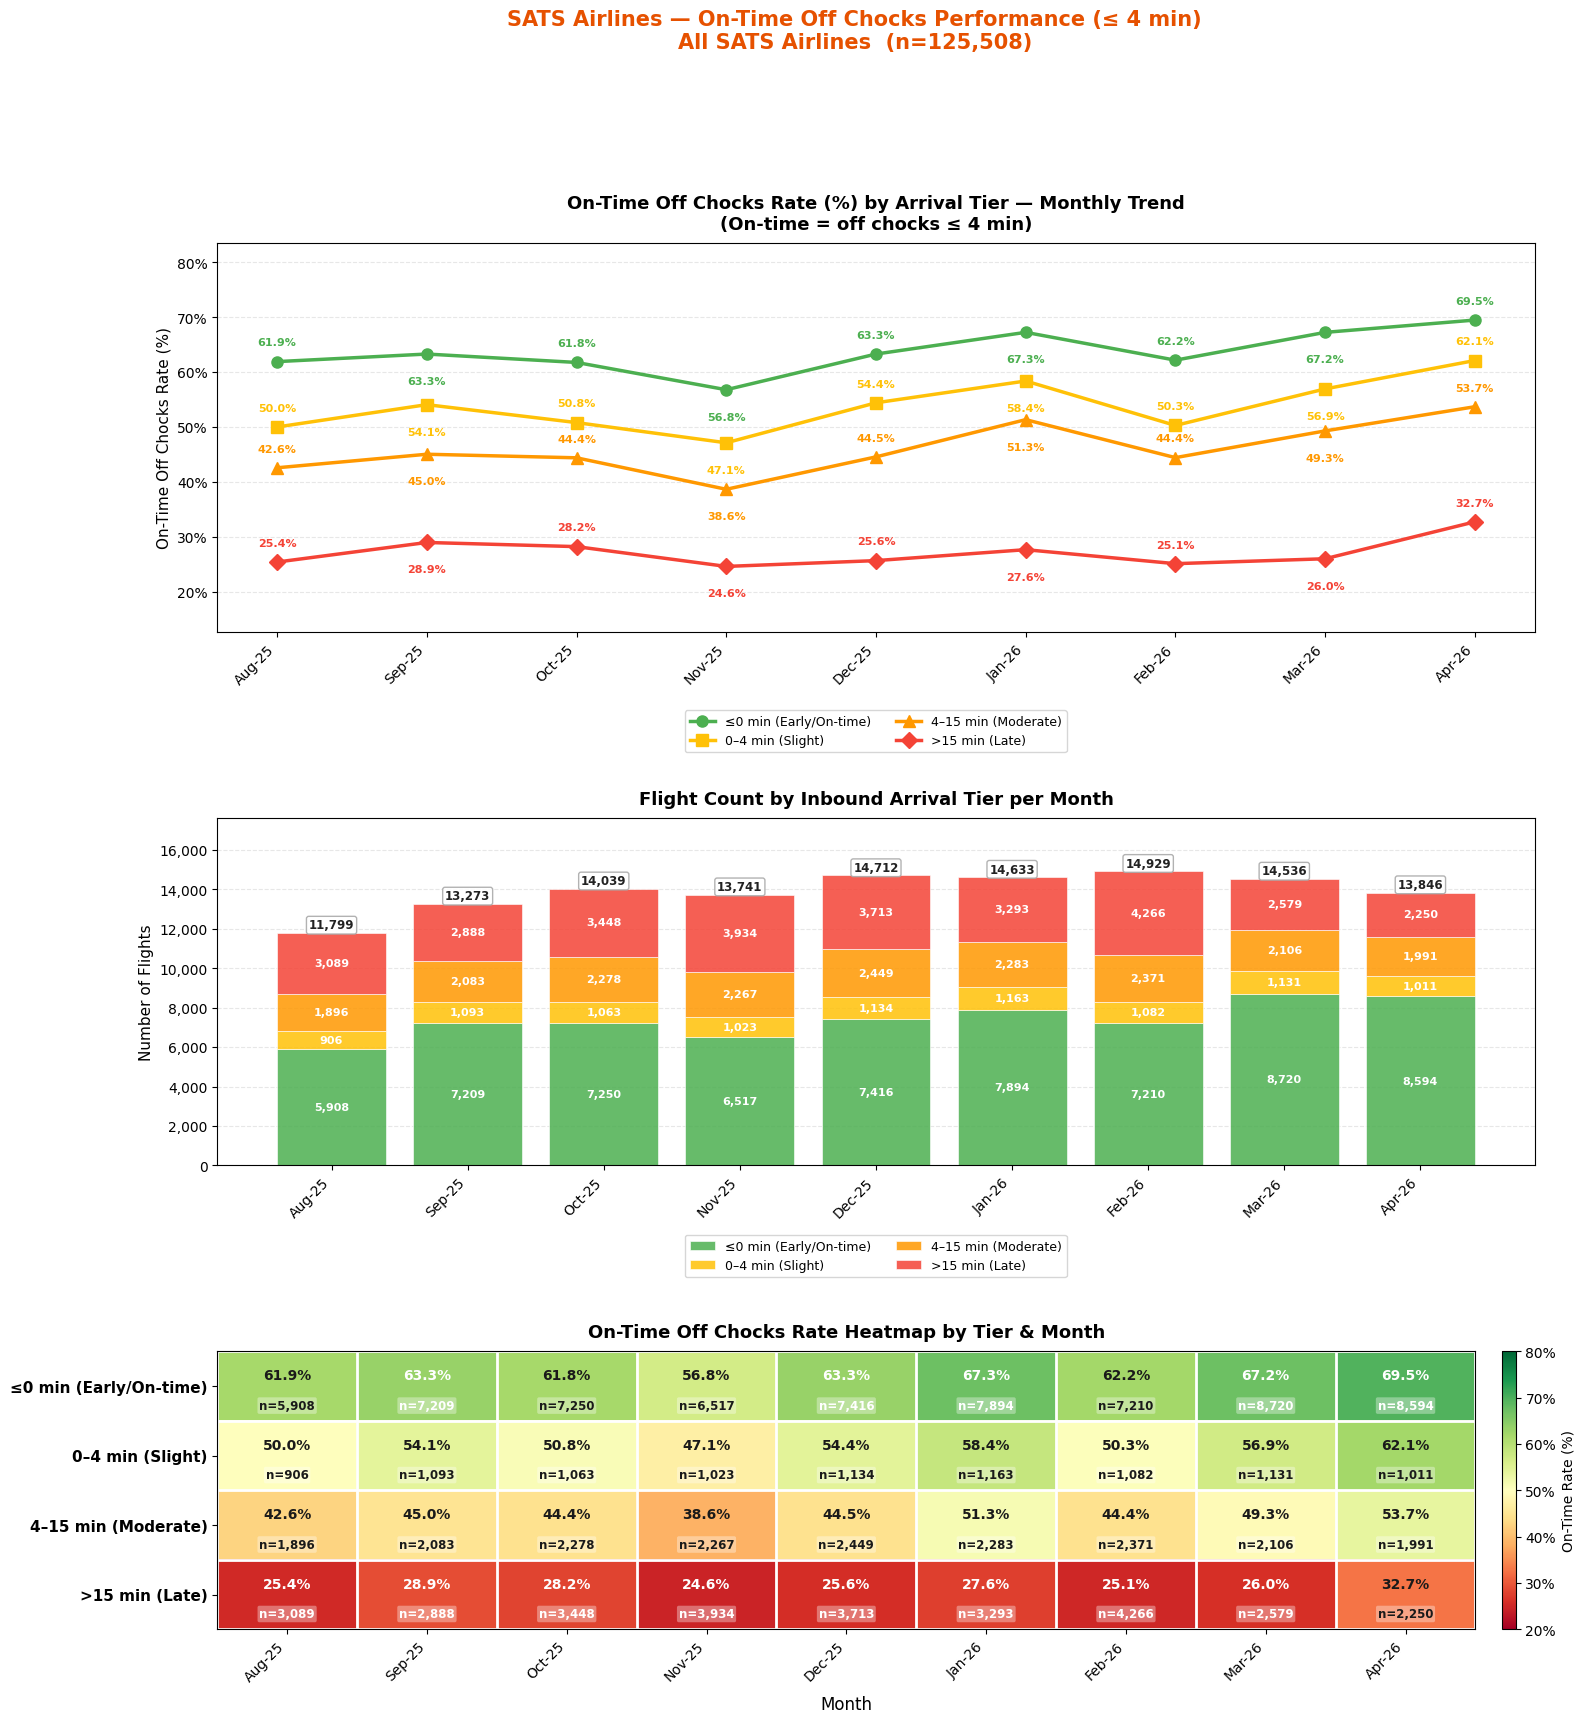

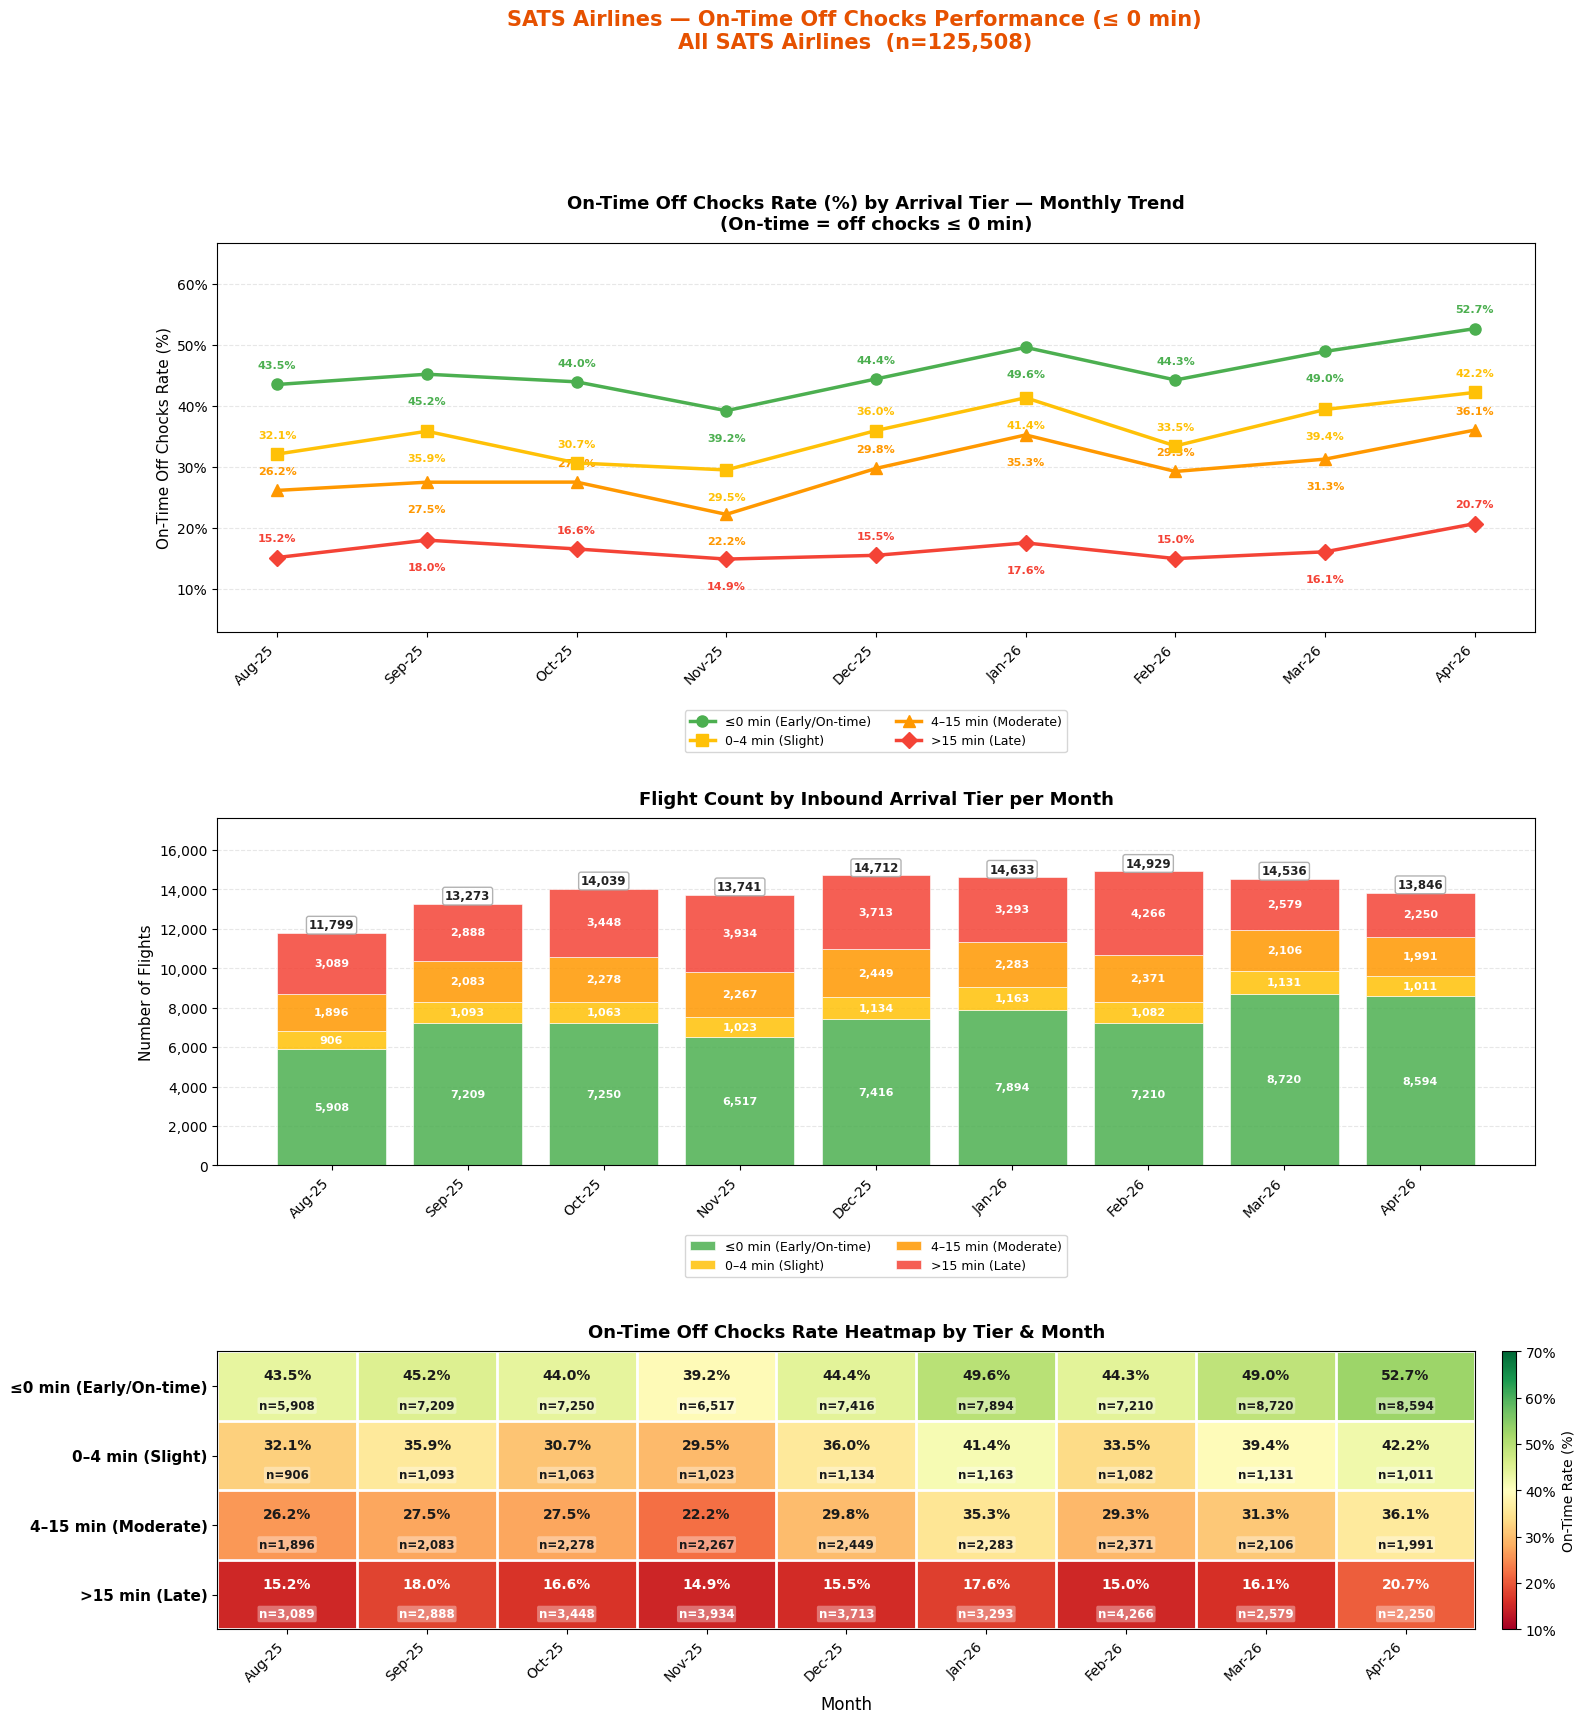

In [15]:
# ── On-Time Off Chocks Performance: All SATS Airlines ─────────────────────
# Shows both thresholds: ≤ 4 min (industry operational) and ≤ 0 min (strict)
_tier_labels  = ['≤0 min (Early/On-time)', '0–4 min (Slight)', '4–15 min (Moderate)', '>15 min (Late)']
_tier_colors  = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
_tier_markers = ['o', 's', '^', 'D']

def _arr_tier_lbl(d):
    if d <= 0:  return '≤0 min (Early/On-time)'
    if d <= 4:  return '0–4 min (Slight)'
    if d <= 15: return '4–15 min (Moderate)'
    return             '>15 min (Late)'

_df_base = df_sats_arr.copy()
_df_base['tier_label'] = _df_base['inbound_delay_mins'].apply(_arr_tier_lbl)

def _draw_combined(df_g, threshold, vmin, vmax, accent='#E65100'):
    _df = df_g.copy()
    _df['dep_ontime'] = (_df['dep_delay_mins'] <= threshold).astype(int)
    _months  = sorted(_df['month_str'].unique())
    _mlabels = [pd.Period(m,'M').to_timestamp().strftime('%b-%y') for m in _months]
    x        = list(range(len(_months)))
    _grp     = _df.groupby(['tier_label','month_str'])
    _rate_df = _grp['dep_ontime'].mean().unstack('month_str').reindex(index=_tier_labels)[_months] * 100
    _cnt_df  = _grp['dep_ontime'].count().unstack('month_str').reindex(index=_tier_labels)[_months]

    fig = plt.figure(figsize=(17, 18))
    gs  = fig.add_gridspec(3, 1, height_ratios=[2.8, 2.5, 2], hspace=0.55)
    ax_line = fig.add_subplot(gs[0])
    ax_bar  = fig.add_subplot(gs[1])
    ax_heat = fig.add_subplot(gs[2])

    for tier, color, marker in zip(_tier_labels, _tier_colors, _tier_markers):
        vals = _rate_df.loc[tier].values
        ax_line.plot(x, vals, color=color, marker=marker, lw=2.5, ms=8, label=tier, zorder=5)
        for i, v in enumerate(vals):
            yo = 10 if i % 2 == 0 else -16; va = 'bottom' if i % 2 == 0 else 'top'
            ax_line.annotate(f'{v:.1f}%', xy=(i,v), xytext=(0,yo), textcoords='offset points',
                             ha='center', va=va, fontsize=8, color=color, fontweight='bold')
    ax_line.set_xticks(x); ax_line.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
    ax_line.set_ylabel('On-Time Off Chocks Rate (%)', fontsize=11)
    ax_line.set_title(f'On-Time Off Chocks Rate (%) by Arrival Tier — Monthly Trend\n'
                      f'(On-time = off chocks ≤ {threshold} min)', fontsize=13, fontweight='bold', pad=10)
    ax_line.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax_line.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, borderaxespad=0)
    ax_line.grid(axis='y', ls='--', alpha=0.3)
    ax_line.set_ylim(_rate_df.values.min()-12, _rate_df.values.max()+14)

    bot = np.zeros(len(_months))
    for tier, color in zip(_tier_labels, _tier_colors):
        vals = _cnt_df.loc[tier].values
        ax_bar.bar(x, vals, bottom=bot, color=color, edgecolor='white', linewidth=0.5, alpha=0.85, label=tier, zorder=2)
        for i,(v,b) in enumerate(zip(vals,bot)):
            if v > 400:
                ax_bar.text(i, b+v*0.5, f'{int(v):,}', ha='center', va='center', fontsize=8,
                            color='white', fontweight='bold', zorder=3)
        bot += vals
    _totals = _cnt_df.sum(axis=0).values
    for i,tot in enumerate(_totals):
        ax_bar.text(i, tot+60, f'{int(tot):,}', ha='center', va='bottom', fontsize=8.5, color='#222',
                    fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.9), zorder=4)
    ax_bar.set_xticks(x); ax_bar.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
    ax_bar.set_ylabel('Number of Flights', fontsize=11)
    ax_bar.set_title('Flight Count by Inbound Arrival Tier per Month', fontsize=13, fontweight='bold', pad=10)
    ax_bar.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{int(v):,}'))
    ax_bar.set_ylim(0, _totals.max()*1.18)
    ax_bar.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, borderaxespad=0)
    ax_bar.grid(axis='y', ls='--', alpha=0.3, zorder=0)

    im = ax_heat.imshow(_rate_df.values, aspect='auto', cmap='RdYlGn',
                        vmin=vmin, vmax=vmax, interpolation='nearest')
    for r in range(len(_tier_labels)):
        for c in range(len(_months)):
            rate=_rate_df.values[r,c]; n=int(_cnt_df.values[r,c])
            tc = 'white' if rate > vmax*0.78 or rate < vmin+(vmax-vmin)*0.2 else '#1a1a1a'
            ax_heat.text(c, r-0.15, f'{rate:.1f}%', ha='center', va='center',
                         fontsize=10, fontweight='bold', color=tc)
            ax_heat.text(c, r+0.28, f'n={n:,}', ha='center', va='center',
                         fontsize=8.5, color=tc, fontweight='bold',
                         bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.35, ec='none'))
    ax_heat.set_xticks(range(len(_months))); ax_heat.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
    ax_heat.set_yticks(range(len(_tier_labels))); ax_heat.set_yticklabels(_tier_labels, fontsize=11, fontweight='bold')
    ax_heat.set_xlabel('Month', fontsize=12, labelpad=8)
    ax_heat.set_title('On-Time Off Chocks Rate Heatmap by Tier & Month', fontsize=13, fontweight='bold', pad=10)
    ax_heat.set_xticks(np.arange(-0.5,len(_months),1), minor=True)
    ax_heat.set_yticks(np.arange(-0.5,len(_tier_labels),1), minor=True)
    ax_heat.grid(which='minor', color='white', linewidth=2); ax_heat.tick_params(which='minor', length=0)
    cbar = plt.colorbar(im, ax=ax_heat, fraction=0.025, pad=0.02)
    cbar.set_label('On-Time Rate (%)', fontsize=10)
    cbar.ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    fig.suptitle(f'SATS Airlines — On-Time Off Chocks Performance (≤ {threshold} min)\nAll SATS Airlines  (n={len(df_g):,})',
                 fontsize=15, fontweight='bold', color=accent, y=1.01)
    plt.show()

_draw_combined(_df_base, threshold=4, vmin=20, vmax=80)
_draw_combined(_df_base, threshold=0, vmin=10, vmax=70)

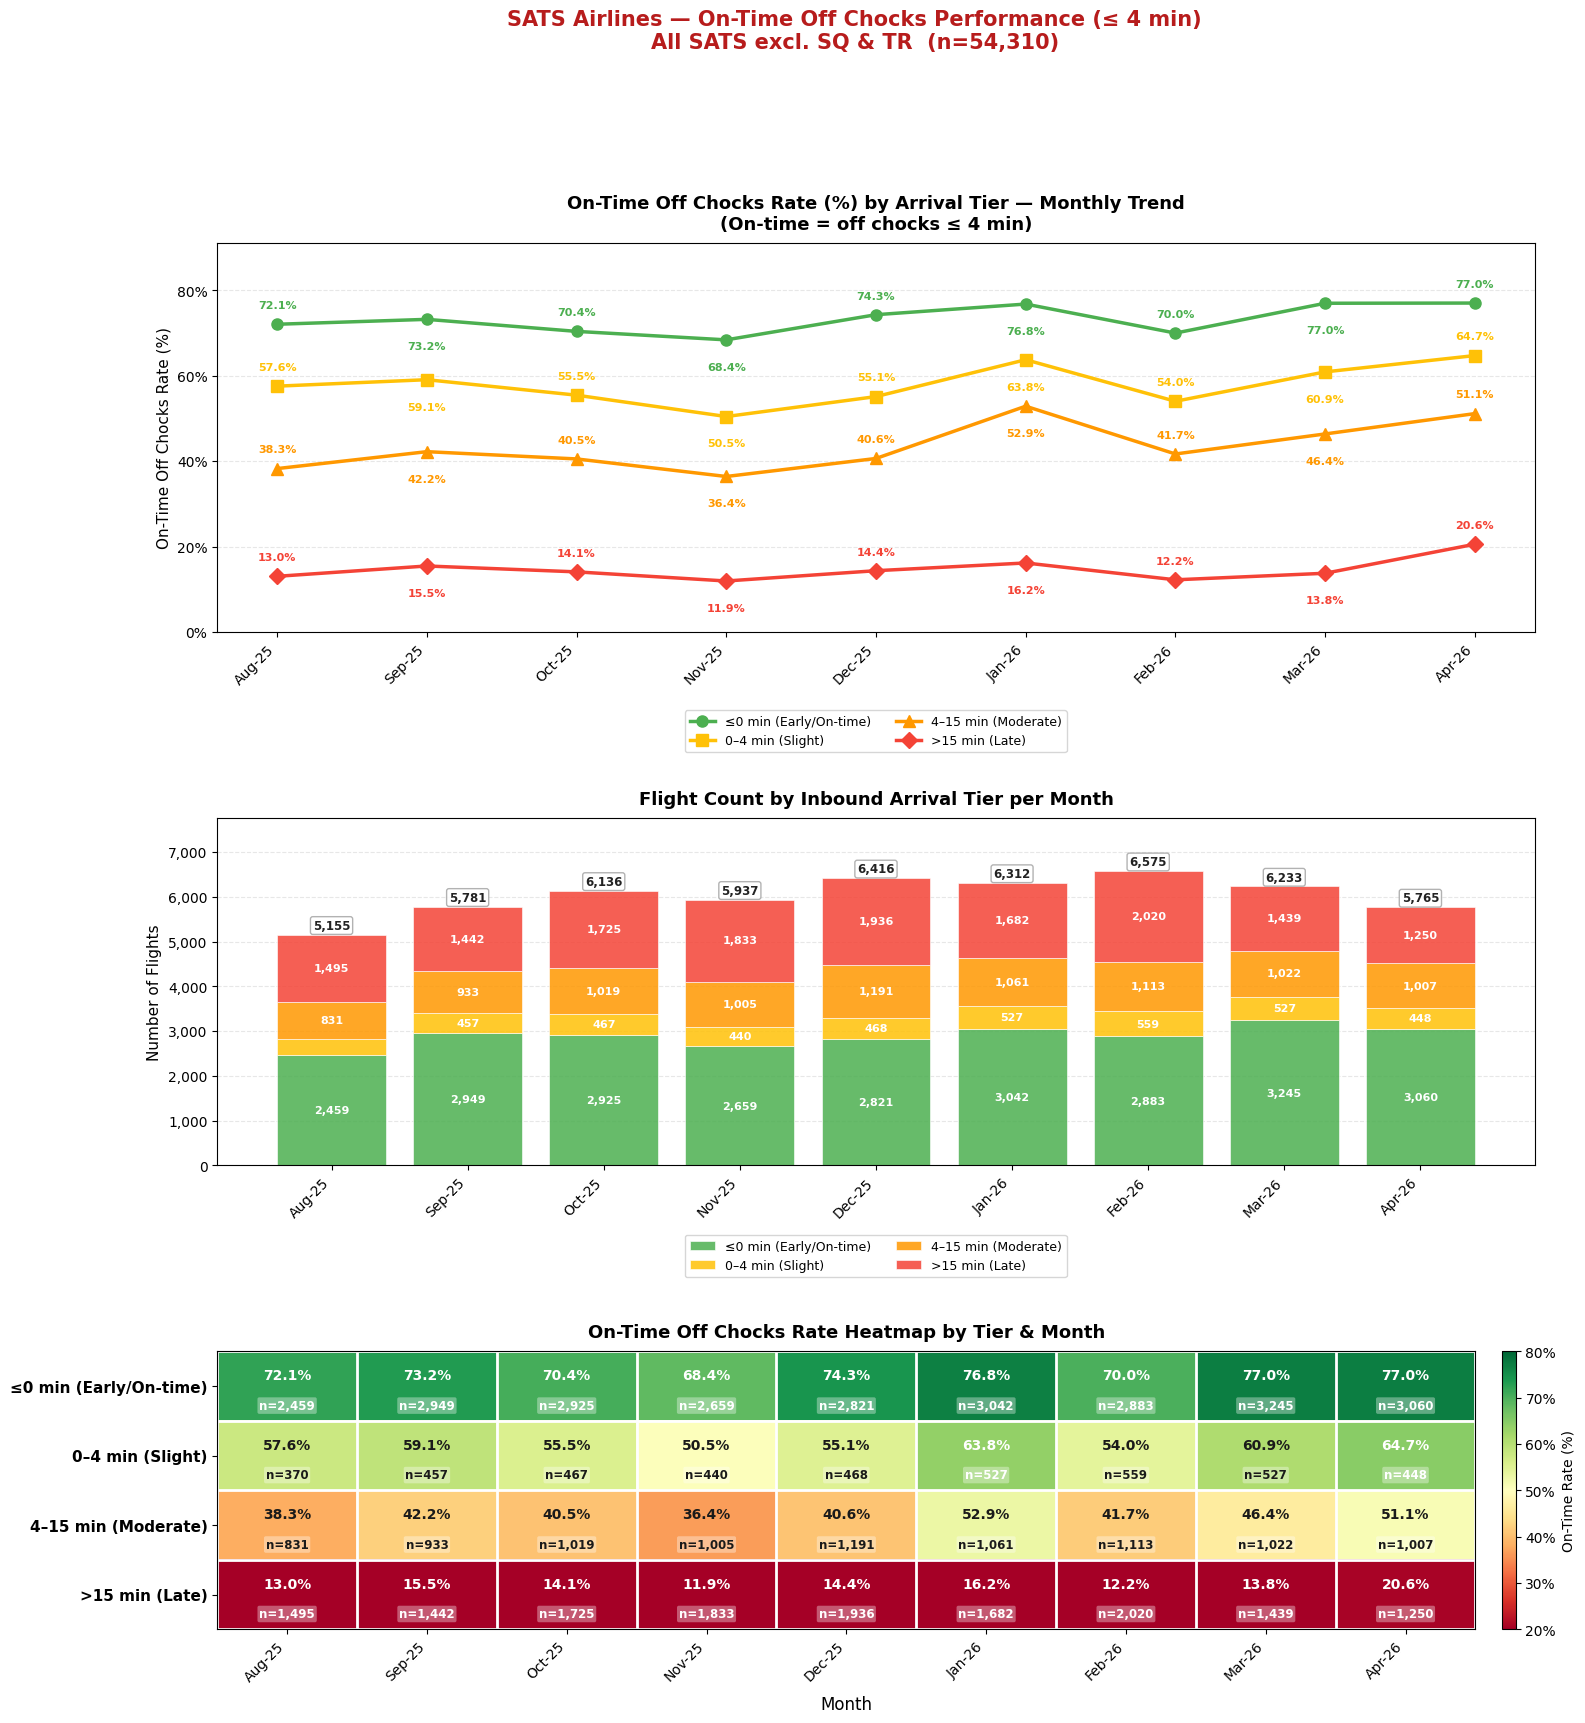

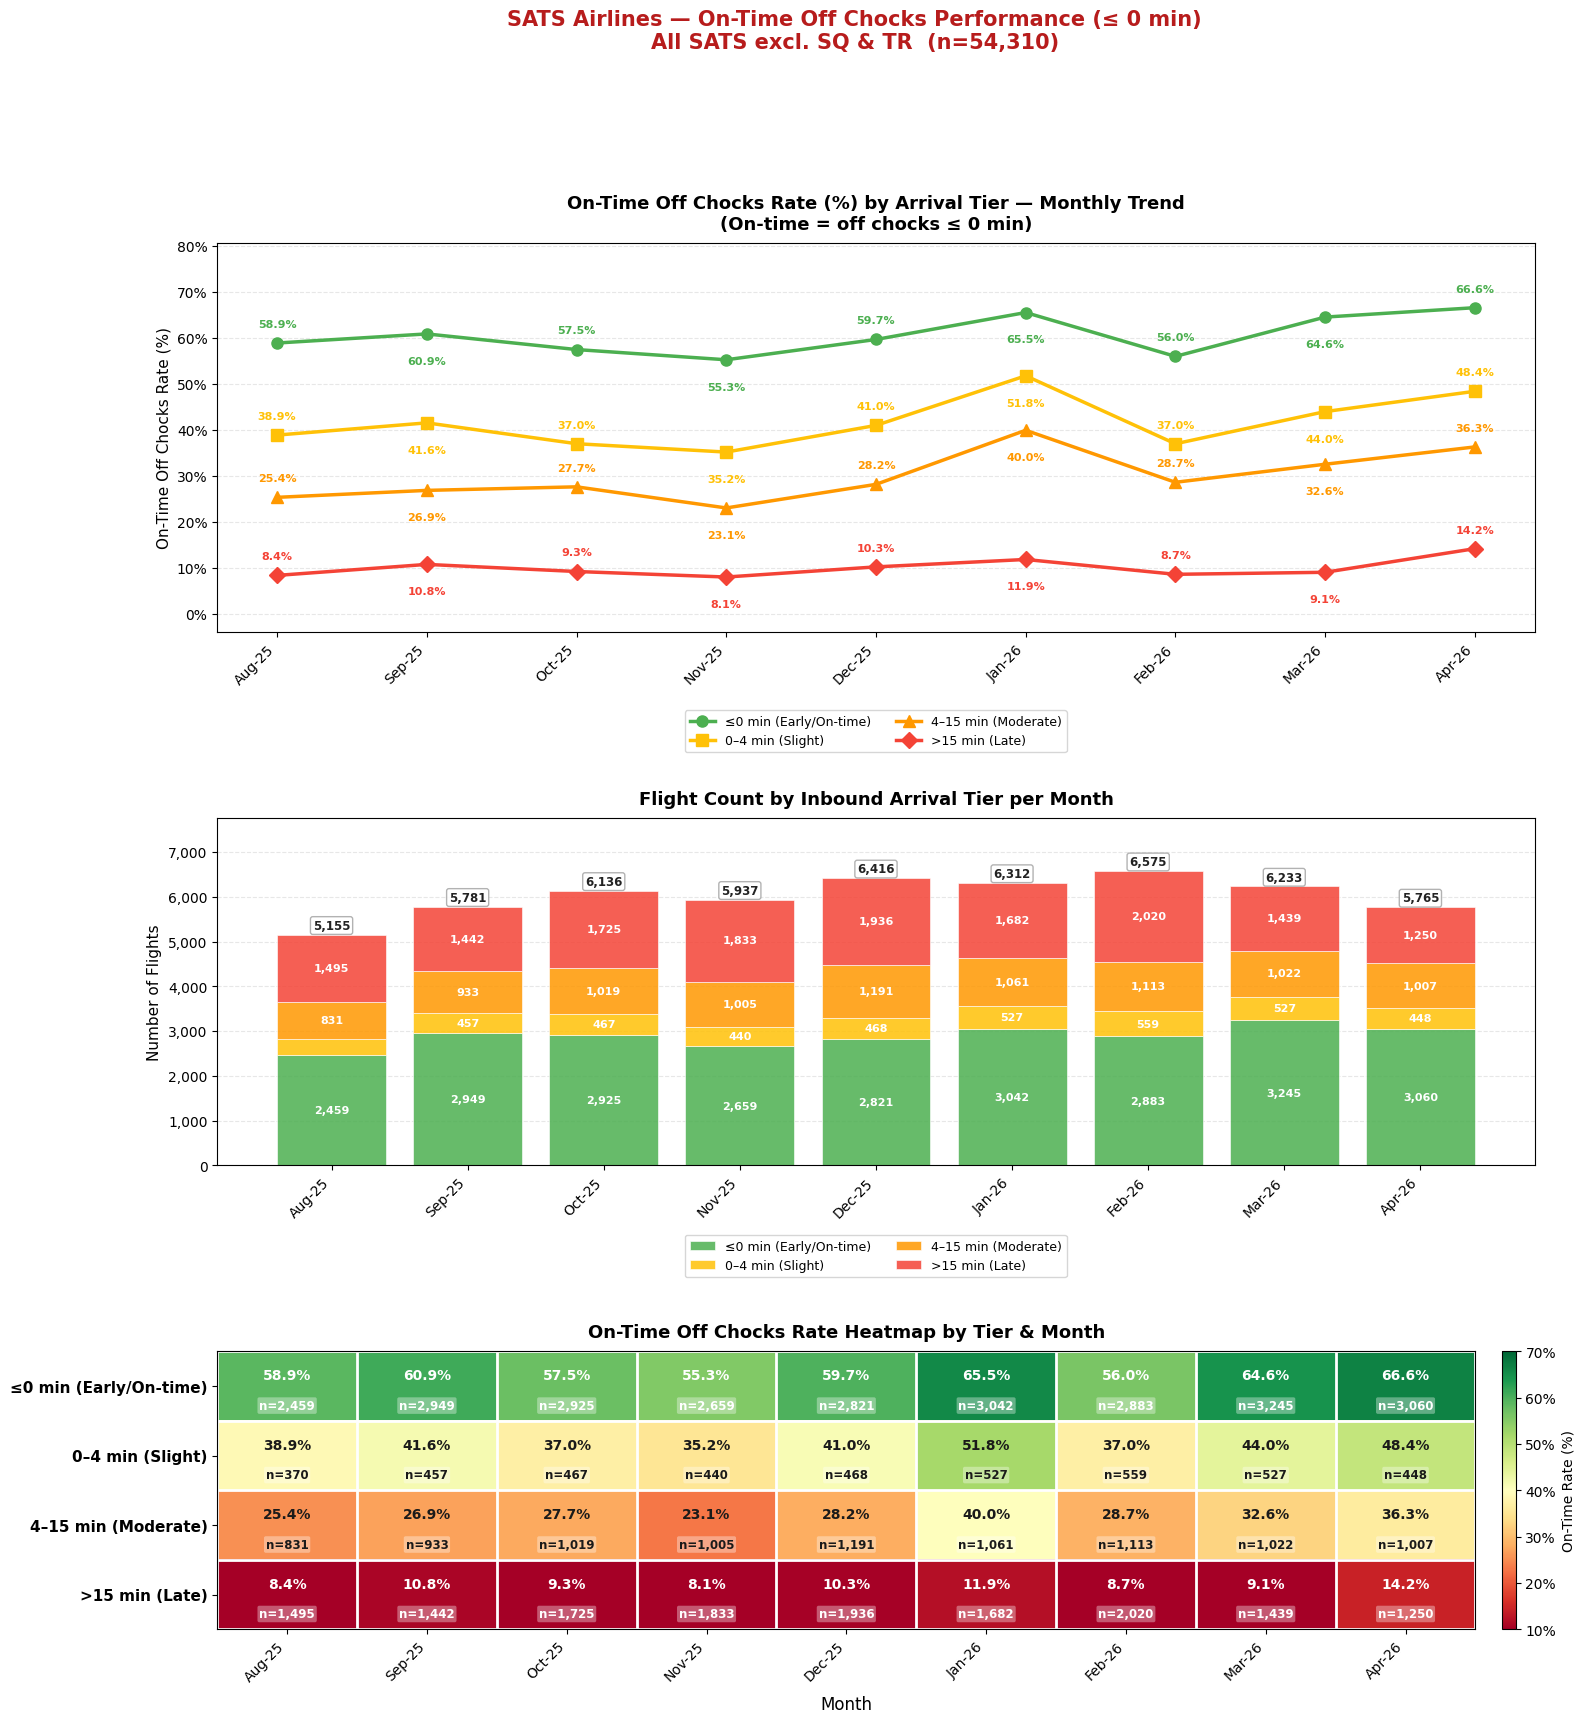

In [16]:
# ── On-Time Off Chocks Performance: All SATS excl. SQ & TR ─────────────────────
# Shows both thresholds: ≤ 4 min (industry operational) and ≤ 0 min (strict)
_tier_labels  = ['≤0 min (Early/On-time)', '0–4 min (Slight)', '4–15 min (Moderate)', '>15 min (Late)']
_tier_colors  = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
_tier_markers = ['o', 's', '^', 'D']

def _arr_tier_lbl(d):
    if d <= 0:  return '≤0 min (Early/On-time)'
    if d <= 4:  return '0–4 min (Slight)'
    if d <= 15: return '4–15 min (Moderate)'
    return             '>15 min (Late)'

_df_base = df_sats_arr[~df_sats_arr['carrier'].isin(HOME)].copy()
_df_base['tier_label'] = _df_base['inbound_delay_mins'].apply(_arr_tier_lbl)

def _draw_combined(df_g, threshold, vmin, vmax, accent='#B71C1C'):
    _df = df_g.copy()
    _df['dep_ontime'] = (_df['dep_delay_mins'] <= threshold).astype(int)
    _months  = sorted(_df['month_str'].unique())
    _mlabels = [pd.Period(m,'M').to_timestamp().strftime('%b-%y') for m in _months]
    x        = list(range(len(_months)))
    _grp     = _df.groupby(['tier_label','month_str'])
    _rate_df = _grp['dep_ontime'].mean().unstack('month_str').reindex(index=_tier_labels)[_months] * 100
    _cnt_df  = _grp['dep_ontime'].count().unstack('month_str').reindex(index=_tier_labels)[_months]

    fig = plt.figure(figsize=(17, 18))
    gs  = fig.add_gridspec(3, 1, height_ratios=[2.8, 2.5, 2], hspace=0.55)
    ax_line = fig.add_subplot(gs[0])
    ax_bar  = fig.add_subplot(gs[1])
    ax_heat = fig.add_subplot(gs[2])

    for tier, color, marker in zip(_tier_labels, _tier_colors, _tier_markers):
        vals = _rate_df.loc[tier].values
        ax_line.plot(x, vals, color=color, marker=marker, lw=2.5, ms=8, label=tier, zorder=5)
        for i, v in enumerate(vals):
            yo = 10 if i % 2 == 0 else -16; va = 'bottom' if i % 2 == 0 else 'top'
            ax_line.annotate(f'{v:.1f}%', xy=(i,v), xytext=(0,yo), textcoords='offset points',
                             ha='center', va=va, fontsize=8, color=color, fontweight='bold')
    ax_line.set_xticks(x); ax_line.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
    ax_line.set_ylabel('On-Time Off Chocks Rate (%)', fontsize=11)
    ax_line.set_title(f'On-Time Off Chocks Rate (%) by Arrival Tier — Monthly Trend\n'
                      f'(On-time = off chocks ≤ {threshold} min)', fontsize=13, fontweight='bold', pad=10)
    ax_line.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax_line.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, borderaxespad=0)
    ax_line.grid(axis='y', ls='--', alpha=0.3)
    ax_line.set_ylim(_rate_df.values.min()-12, _rate_df.values.max()+14)

    bot = np.zeros(len(_months))
    for tier, color in zip(_tier_labels, _tier_colors):
        vals = _cnt_df.loc[tier].values
        ax_bar.bar(x, vals, bottom=bot, color=color, edgecolor='white', linewidth=0.5, alpha=0.85, label=tier, zorder=2)
        for i,(v,b) in enumerate(zip(vals,bot)):
            if v > 400:
                ax_bar.text(i, b+v*0.5, f'{int(v):,}', ha='center', va='center', fontsize=8,
                            color='white', fontweight='bold', zorder=3)
        bot += vals
    _totals = _cnt_df.sum(axis=0).values
    for i,tot in enumerate(_totals):
        ax_bar.text(i, tot+60, f'{int(tot):,}', ha='center', va='bottom', fontsize=8.5, color='#222',
                    fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.9), zorder=4)
    ax_bar.set_xticks(x); ax_bar.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
    ax_bar.set_ylabel('Number of Flights', fontsize=11)
    ax_bar.set_title('Flight Count by Inbound Arrival Tier per Month', fontsize=13, fontweight='bold', pad=10)
    ax_bar.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{int(v):,}'))
    ax_bar.set_ylim(0, _totals.max()*1.18)
    ax_bar.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2, borderaxespad=0)
    ax_bar.grid(axis='y', ls='--', alpha=0.3, zorder=0)

    im = ax_heat.imshow(_rate_df.values, aspect='auto', cmap='RdYlGn',
                        vmin=vmin, vmax=vmax, interpolation='nearest')
    for r in range(len(_tier_labels)):
        for c in range(len(_months)):
            rate=_rate_df.values[r,c]; n=int(_cnt_df.values[r,c])
            tc = 'white' if rate > vmax*0.78 or rate < vmin+(vmax-vmin)*0.2 else '#1a1a1a'
            ax_heat.text(c, r-0.15, f'{rate:.1f}%', ha='center', va='center',
                         fontsize=10, fontweight='bold', color=tc)
            ax_heat.text(c, r+0.28, f'n={n:,}', ha='center', va='center',
                         fontsize=8.5, color=tc, fontweight='bold',
                         bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.35, ec='none'))
    ax_heat.set_xticks(range(len(_months))); ax_heat.set_xticklabels(_mlabels, rotation=45, ha='right', fontsize=10)
    ax_heat.set_yticks(range(len(_tier_labels))); ax_heat.set_yticklabels(_tier_labels, fontsize=11, fontweight='bold')
    ax_heat.set_xlabel('Month', fontsize=12, labelpad=8)
    ax_heat.set_title('On-Time Off Chocks Rate Heatmap by Tier & Month', fontsize=13, fontweight='bold', pad=10)
    ax_heat.set_xticks(np.arange(-0.5,len(_months),1), minor=True)
    ax_heat.set_yticks(np.arange(-0.5,len(_tier_labels),1), minor=True)
    ax_heat.grid(which='minor', color='white', linewidth=2); ax_heat.tick_params(which='minor', length=0)
    cbar = plt.colorbar(im, ax=ax_heat, fraction=0.025, pad=0.02)
    cbar.set_label('On-Time Rate (%)', fontsize=10)
    cbar.ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    fig.suptitle(f'SATS Airlines — On-Time Off Chocks Performance (≤ {threshold} min)\nAll SATS excl. SQ & TR  (n={len(df_g):,})',
                 fontsize=15, fontweight='bold', color=accent, y=1.01)
    plt.show()

_draw_combined(_df_base, threshold=4, vmin=20, vmax=80)
_draw_combined(_df_base, threshold=0, vmin=10, vmax=70)

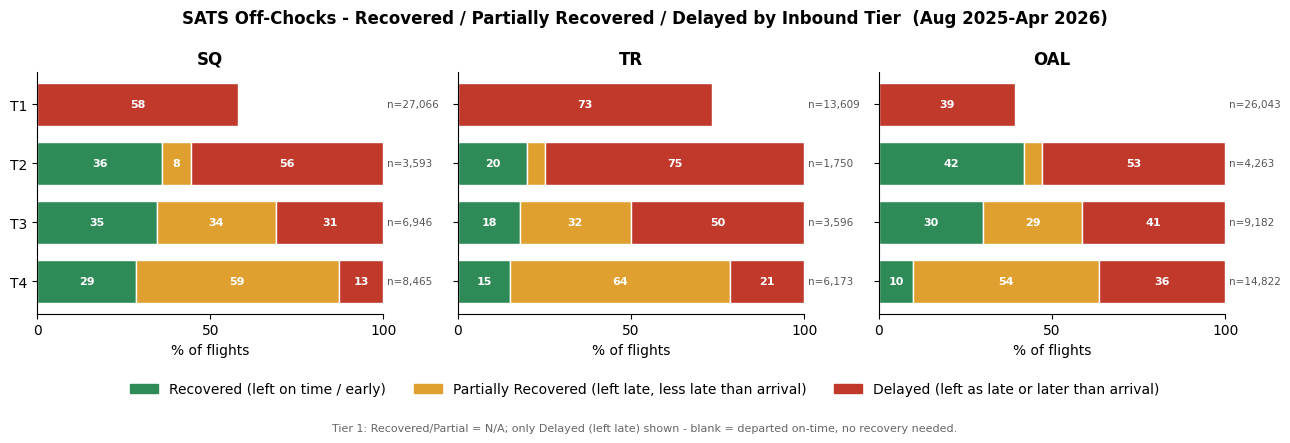

SQ                                TR            \
                               n Recovered Partial Delayed       n Recovered   
Tier 1 - On-time (<=0)   27066.0       NaN     NaN    58.1 13609.0       NaN   
Tier 2 - Slight (0-4)     3593.0      36.2     8.2    55.6  1750.0      20.1   
Tier 3 - Moderate (4-15)  6946.0      34.6    34.4    31.0  3596.0      18.0   
Tier 4 - Late (>15)       8465.0      28.5    58.6    12.9  6173.0      15.1   

                                             OAL                            
                         Partial Delayed       n Recovered Partial Delayed  
Tier 1 - On-time (<=0)       NaN    73.4 26043.0       NaN     NaN    39.2  
Tier 2 - Slight (0-4)        5.1    74.9  4263.0      41.8     5.4    52.8  
Tier 3 - Moderate (4-15)    31.8    50.2  9182.0      30.0    28.8    41.2  
Tier 4 - Late (>15)         63.5    21.4 14822.0       9.9    53.6    36.4

In [18]:
# ============================================================================
# SATS CONTRIBUTION - Recovered / Partially Recovered / Delayed, by inbound tier x carrier
# ----------------------------------------------------------------------------
# ASSUMPTIONS
#  1. Uses df_sats_arr (working set built above: 125,508 flights, SATS-handled,
#     Aug 2025-Apr 2026, outlier-filtered). Run the pipeline cell first.
#  2. inbound = arr_actual - arr_scheduled ; dep = dep_actual - dep_scheduled (off-chocks). on-time = <=0.
#  3. TIER = inbound (arrival) delay tier, fixed at arrival:
#       T1 <=0 | T2 0-4 | T3 4-15 | T4 >15  (minutes).
#  4. CATEGORY = the OUTCOME at off-chocks (what matters is whether it left by schedule,
#     NOT how many minutes were saved):
#       RECOVERED            dep <= 0            left ON TIME / EARLY (full recovery, regardless of how late it arrived)
#       PARTIALLY RECOVERED  0 < dep < inbound   left LATE but LESS late than it arrived (clawed back some, not all)
#       DELAYED              dep >= inbound      left AS LATE or LATER than it arrived (no recovery / carried full delay or worse)
#     For tiers 2-4 the three sum to 100%.
#  5. TIER 1 (on-time arrival, nothing to recover):
#       RECOVERED = N/A ; PARTIALLY RECOVERED = N/A ; DELAYED = dep > 0 (SATS-contributed late departure).
#       An early arrival that leaves on time is NOT delayed/partial - it is the implicit on-time bucket (blank).
#  6. OAL = all SATS-handled carriers EXCEPT SQ and TR.
# ============================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

assert 'df_sats_arr' in globals(), "Run the working-set pipeline cell (df_sats_arr) first."

C_REC, C_PAR, C_DEL = "#2E8B57", "#E0A030", "#C0392B"   # green / amber / red

_w = df_sats_arr.copy()
_w["tier"] = np.select([_w.inbound_delay_mins <= 0, _w.inbound_delay_mins <= 4,
                        _w.inbound_delay_mins <= 15], [1, 2, 3], default=4)
_w["grp"]  = np.where(_w.carrier == "SQ", "SQ", np.where(_w.carrier == "TR", "TR", "OAL"))

def _cell(sub):
    n = len(sub)
    if n == 0:
        return n, np.nan, np.nan, np.nan
    dep, inb = sub.dep_delay_mins, sub.inbound_delay_mins
    if sub["tier"].iloc[0] == 1:                                  # assumption 5
        return n, np.nan, np.nan, (dep > 0).mean()*100
    rec = (dep <= 0).mean()*100
    par = ((dep > 0) & (dep < inb)).mean()*100
    dly = (dep >= inb).mean()*100
    return n, rec, par, dly

TIERS  = {1:"Tier 1 - On-time (<=0)", 2:"Tier 2 - Slight (0-4)",
          3:"Tier 3 - Moderate (4-15)", 4:"Tier 4 - Late (>15)"}
GROUPS = ["SQ", "TR", "OAL"]

rows = []
for t in (1, 2, 3, 4):
    r = {}
    for g in GROUPS:
        n, rec, par, dly = _cell(_w[(_w.tier == t) & (_w.grp == g)])
        r[(g,"n")] = n; r[(g,"Recovered")] = rec; r[(g,"Partial")] = par; r[(g,"Delayed")] = dly
    rows.append(pd.Series(r, name=TIERS[t]))
res = pd.DataFrame(rows); res.columns = pd.MultiIndex.from_tuples(res.columns)

# ---- styled table (renders inline in Jupyter) ----
disp = res.copy()
for c in disp.columns:
    disp[c] = (disp[c].map(lambda v: f"{int(v):,}") if c[1] == "n"
               else disp[c].map(lambda v: "N/A" if pd.isna(v) else f"{v:.0f}%"))
def _bg(col):
    clr = {"Recovered":"#e9f3ee", "Partial":"#fdf3e2", "Delayed":"#f7e7e5"}.get(col.name[1], "#ffffff")
    return [f"background-color:{clr}"] * len(col)
styler = (disp.style.apply(_bg, axis=0)
          .set_caption("SATS contribution by inbound tier - Recovered (left on time/early) / "
                       "Partial = partially recovered (left late, less late than arrival) / "
                       "Delayed (left as late or later than arrival).  % of cell, n = flights.")
          .set_table_styles([{"selector":"caption","props":[("font-weight","bold"),("font-size","12.5px"),("padding","6px")]}]))
display(styler)

# ---- stacked bars (one panel per carrier) ----
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7), sharey=True)
for ax, g in zip(axes, GROUPS):
    ys = np.arange(4)[::-1]
    for k, t in enumerate((1, 2, 3, 4)):
        rec = res.loc[TIERS[t], (g,"Recovered")]
        par = res.loc[TIERS[t], (g,"Partial")]
        dly = res.loc[TIERS[t], (g,"Delayed")]
        left = 0
        for val, clr in [(0 if pd.isna(rec) else rec, C_REC),
                         (0 if pd.isna(par) else par, C_PAR),
                         (dly, C_DEL)]:
            if val and val > 0:
                ax.barh(ys[k], val, left=left, color=clr, edgecolor="white", height=0.72)
                if val >= 7:
                    ax.text(left + val/2, ys[k], f"{val:.0f}", va="center", ha="center",
                            color="white", fontsize=8, fontweight="bold")
                left += val
        ax.text(101, ys[k], f"n={int(res.loc[TIERS[t],(g,'n')]):,}", va="center", ha="left",
                fontsize=7.5, color="#555")
    ax.set_yticks(ys); ax.set_yticklabels([f"T{t}" for t in (1,2,3,4)])
    ax.set_xlim(0, 100); ax.set_xticks([0, 50, 100]); ax.set_xlabel("% of flights")
    ax.set_title(g, fontweight="bold"); ax.spines[["top","right"]].set_visible(False)
fig.suptitle("SATS Off-Chocks - Recovered / Partially Recovered / Delayed by Inbound Tier  (Aug 2025-Apr 2026)",
             fontweight="bold")
fig.legend(handles=[Patch(color=C_REC, label="Recovered (left on time / early)"),
                    Patch(color=C_PAR, label="Partially Recovered (left late, less late than arrival)"),
                    Patch(color=C_DEL, label="Delayed (left as late or later than arrival)")],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.10))
fig.text(0.5, -0.16, "Tier 1: Recovered/Partial = N/A; only Delayed (left late) shown - blank = departed on-time, no recovery needed.",
         ha="center", fontsize=8, color="#666")
plt.tight_layout(); plt.show()

res  # raw numbers


---
## 6. Key Takeaways

### Finding 1 — Inbound delay is the strongest predictor of off-chocks delay
The on-time off-chocks rate drops from **46.1%** for early/on-time arrivals to just **16.4%** for flights arriving more than 15 minutes late — a **29.8 percentage-point** deterioration. This holds consistently across all 9 months, confirming it is a structural relationship, not a seasonal effect.

### Finding 2 — The majority of inbound aircraft do not arrive on time
**39.2%** of inbound aircraft arrive more than 4 minutes late, and **23.5%** arrive more than 15 minutes late. Since turnaround time is fixed, a late arrival directly compresses the time available for ground operations, making on-time pushback extremely difficult regardless of ground crew performance.

### Finding 3 — Even on-time arrivals have a low on-time pushback rate
When inbound aircraft arrive on time, only **46.1%** push back on time. This suggests that factors beyond inbound delay — such as boarding completion, cargo loading, fuelling, or gate availability — also contribute significantly to off-chocks delay.

### Finding 4 — Singapore home carriers (SQ & TR) outperform other carriers
SQ and TR, which together account for **56.7%** of SATS-handled flights, consistently show higher on-time off-chocks rates across all arrival tiers. For late arrivals (>15 min), SQ & TR achieve approximately **2× the on-time rate** of non-home carriers, pointing to a structural home-base advantage in crew, maintenance, and operational recovery.

### Finding 5 — Monthly trends are stable; no single month explains the pattern
The heatmap charts show that low on-time rates for late-arriving aircraft are present in every month of the 9-month dataset, not concentrated in a specific period. Seasonal effects exist but are secondary to the tier-level structural relationship.

---

---
*Report generated from SATS operational data. All figures based on the working dataset of 134,380 flights (Aug 2025 – May 2026) after applying data quality and coverage filters described in Section 2.*